In [5]:
from enum import StrEnum


class RuntimeEnvironment(StrEnum):
    colab = "colab"
    local = "local"

In [6]:
RUNTIME_ENVIRONMENT = RuntimeEnvironment.local

In [7]:
if RUNTIME_ENVIRONMENT == RuntimeEnvironment.colab:
    !pip install lightning pydantic pydantic-settings optuna optuna-integration
    !pip install aiohttp==3.9.5 gcsfs==2024.2.0 fsspec==2024.2.0

    from google.colab import drive

    # Mount google drive
    drive.mount('/content/drive', force_remount=True)

    import os

    # Change working directory to coding environment
    from google.colab import userdata

    os.chdir(userdata.get("colab_cwd"))

In [8]:
from pathlib import Path

cwd = Path.cwd()
print(cwd)

C:\Users\arya\OneDrive\TA\Coding


In [9]:
from ta_module.config import DotEnv, Config, load_config, load_dot_env

DOT_ENV: DotEnv = load_dot_env()
CONFIG: Config = load_config(DOT_ENV.config_file)

print(f"DOT_ENV:\n{DOT_ENV}")
print(f"\nCONFIG:\n{CONFIG}")

DOT_ENV:
plots_dir=WindowsPath('plots') tuning_logs_dir=WindowsPath('logs/tuning') training_logs_dir=WindowsPath('logs/training') tuning_checkpoints_dir=WindowsPath('checkpoints/tuning') training_checkpoints_dir=WindowsPath('checkpoints/training') results_dir=WindowsPath('results') last_tune_metadata_file=WindowsPath('metadatas/last_tune_metadata.json') last_train_metadata_file=WindowsPath('metadatas/last_train_metadata.json') config_file=WindowsPath('config.yaml') mortalitas_file=WindowsPath('data/mortalitas.csv') populasi_file=WindowsPath('data/populasi.csv') bi_rate_file=WindowsPath('data/bi_rate.csv') optuna_db_url='sqlite:///optuna_study.db'

CONFIG:
mode=<ModeEnum.INFERENCE: 'inference'> seed=42 split=Split(train=0.7, validation=0.15, test=0.15) data=DataConfig(mortalitas=Mortalitas(year_col='year', date_format='%Y', age_col='age', gender_col='gender', mortality_col='mortality_rate'), bi_rate=BIRate(date_col='date', date_format='%d-%m-%y')) dataset=DatasetConfig(lookback=10, hori

In [10]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Available device: {DEVICE}")

Available device: cpu


In [11]:
from lightning import seed_everything

seed_everything(CONFIG.seed, workers=True)

Seed set to 42


42

# Analisis karakteristik data

## Load data dari penyimpanan

In [12]:
MORTALITAS_CONFIG = CONFIG.data.mortalitas

YEAR_COL = MORTALITAS_CONFIG.year_col
AGE_COL = MORTALITAS_CONFIG.age_col
GENDER_COL = MORTALITAS_CONFIG.gender_col
MORTALITY_COL = MORTALITAS_CONFIG.mortality_col

BI_RATE_CONFIG = CONFIG.data.bi_rate

In [13]:
import pandas as pd

mortalitas_df = pd.read_csv(
    DOT_ENV.mortalitas_file, parse_dates=[YEAR_COL], date_format=MORTALITAS_CONFIG.date_format
)

populasi_df = pd.read_csv(DOT_ENV.populasi_file)

bi_rate_df = pd.read_csv(
    DOT_ENV.bi_rate_file, parse_dates=[BI_RATE_CONFIG.date_col], date_format=BI_RATE_CONFIG.date_format
)

In [14]:
AGE_MIN: int = min(mortalitas_df[AGE_COL])
AGE_MAX: int = max(mortalitas_df[AGE_COL])

YEAR_MIN: int = min(mortalitas_df[YEAR_COL].dt.year)
YEAR_MAX: int = max(mortalitas_df[YEAR_COL].dt.year)

## Analisa statistika deskriptif

In [15]:
mortalitas_df.head()

,year,gender,age,mortality_rate
0,1950-01-01,Male,0,0.228515
1,1950-01-01,Female,0,0.185158
2,1950-01-01,Male,1,0.069349
3,1950-01-01,Female,1,0.063058
4,1950-01-01,Male,2,0.044724


In [16]:
mortalitas_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15150 entries, 0 to 15149
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   year            15150 non-null  datetime64[us]
 1   gender          15150 non-null  str           
 2   age             15150 non-null  int64         
 3   mortality_rate  15150 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1), str(1)
memory usage: 473.6 KB


In [17]:
mortalitas_statdesc_df = mortalitas_df.groupby([GENDER_COL, AGE_COL])[MORTALITY_COL].aggregate(
    ["mean", "std", "min", "median", "max"]
)
mortalitas_statdesc_df.to_csv(DOT_ENV.results_dir / "mortalitas_statdesc.csv")

Berhasil tersimpan!


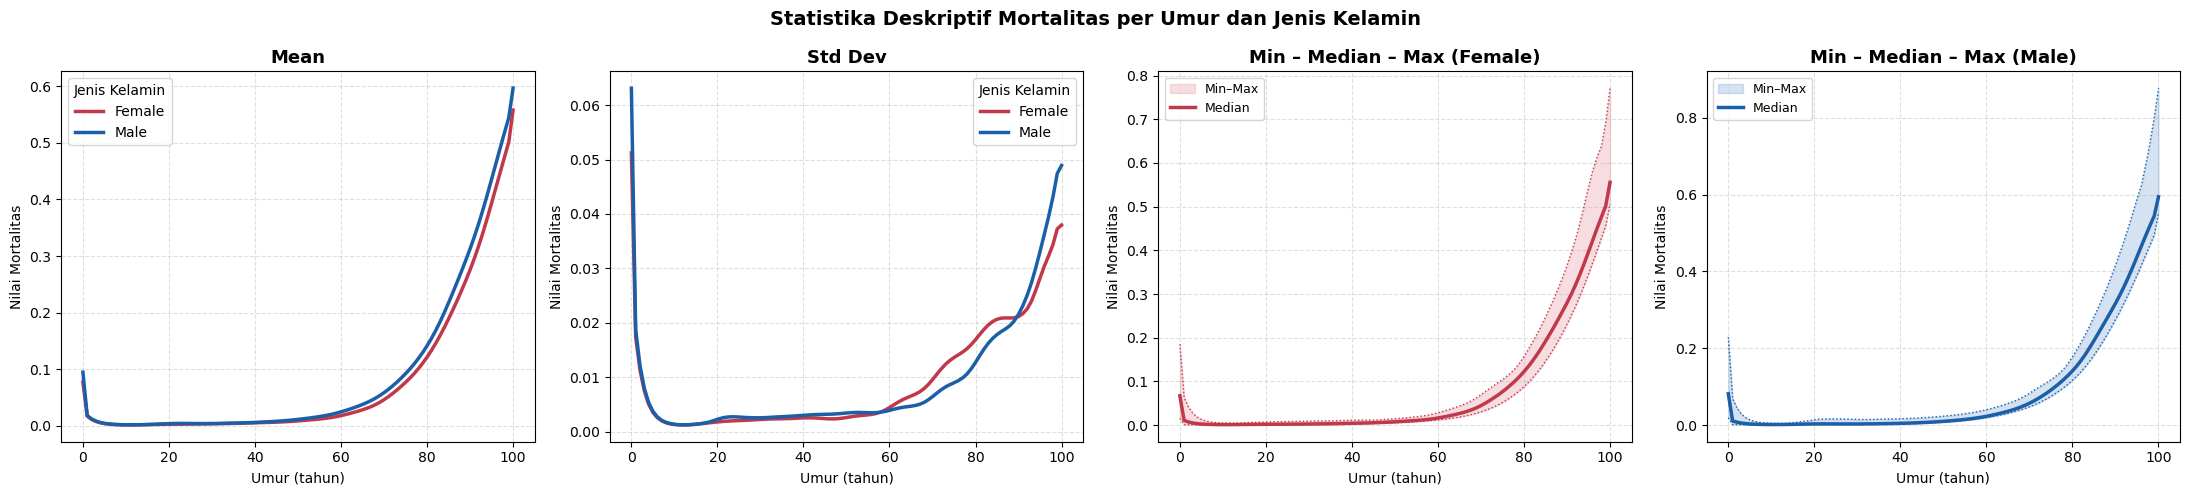

In [18]:
from ta_module.utils import plot_mortalitas_statdesc

mortalitas_statdesc_df = pd.read_csv(DOT_ENV.results_dir / "mortalitas_statdesc.csv")
plot_mortalitas_statdesc(df=mortalitas_statdesc_df, plots_dir=DOT_ENV.plots_dir)

In [19]:
populasi_df.head()

,gender,age,value
0,Male,45,2013106
1,Male,46,1965078
2,Male,47,1918556
3,Male,48,1880902
4,Male,49,1836713


In [20]:
populasi_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   gender  32 non-null     str  
 1   age     32 non-null     int64
 2   value   32 non-null     int64
dtypes: int64(2), str(1)
memory usage: 900.0 bytes


In [21]:
bi_rate_df.head()

,date,bi_rate
0,2024-12-18,0.0600
1,2024-11-20,0.0600
2,2024-10-16,0.0600
3,2024-09-18,0.0600
4,2024-08-21,0.0625


In [22]:
bi_rate_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     60 non-null     datetime64[us]
 1   bi_rate  60 non-null     float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 1.1 KB


## Histogram mortalitas

In [23]:
import torch
import numpy as np

# Male mortalitas
mortalitas_df_male = mortalitas_df[mortalitas_df[GENDER_COL] == "Male"]
M_male = mortalitas_df_male.pivot(
    index=YEAR_COL,
    columns=AGE_COL,
    values=MORTALITY_COL
)
M_male = torch.from_numpy(M_male.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

# Female mortalitas
mortalitas_df_female = mortalitas_df[mortalitas_df[GENDER_COL] == "Female"]
M_female = mortalitas_df_female.pivot(
    index=YEAR_COL,
    columns=AGE_COL,
    values=MORTALITY_COL
)
M_female = torch.from_numpy(M_female.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

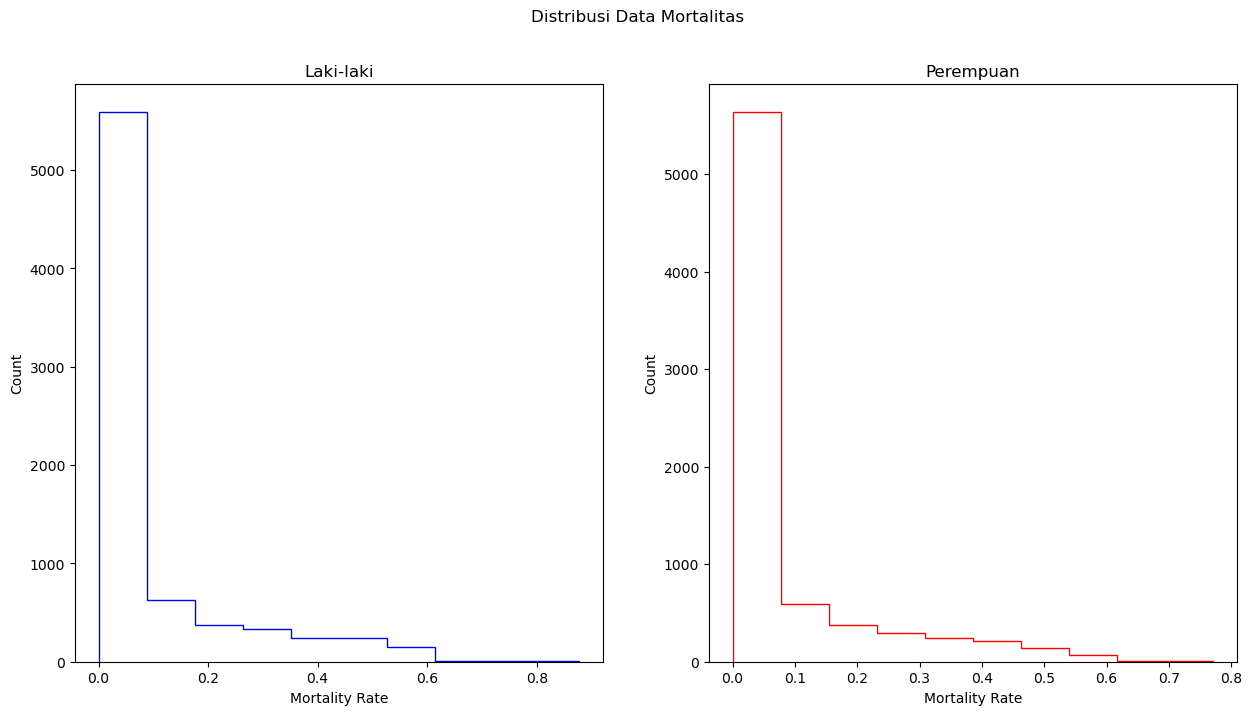

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].hist(M_male.cpu().numpy().reshape(-1), color="blue", histtype="step")
ax[0].set_title("Laki-laki")
ax[0].set_xlabel("Mortality Rate")
ax[0].set_ylabel("Count")

ax[1].hist(M_female.cpu().numpy().reshape(-1), color="red", histtype="step")
ax[1].set_title("Perempuan")
ax[1].set_xlabel("Mortality Rate")
ax[1].set_ylabel("Count")

fig.suptitle("Distribusi Data Mortalitas")
fig.savefig(DOT_ENV.plots_dir / "distribusi_data_mortalitas.png")
plt.show()

## Plot mortalitas satu usia untuk semua tahun

In [25]:
import seaborn as sns

sns.set_theme(style="whitegrid")

In [26]:
plots_dir = DOT_ENV.plots_dir

In [27]:
from ta_module.utils import plot_usia_vs_tahun


def wrapper_plot_usia_vs_tahun(age_start: int, age_end: int):
    plot_usia_vs_tahun(
        mortalitas_df=mortalitas_df,
        age_col=AGE_COL,
        year_col=YEAR_COL,
        gender_col=GENDER_COL,
        mortality_col=MORTALITY_COL,
        age_start=age_start,
        age_end=age_end,
        plots_dir=plots_dir
    )

Plot usia vs tahun (0-100) saved to plots\usia vs tahun (0-100).png


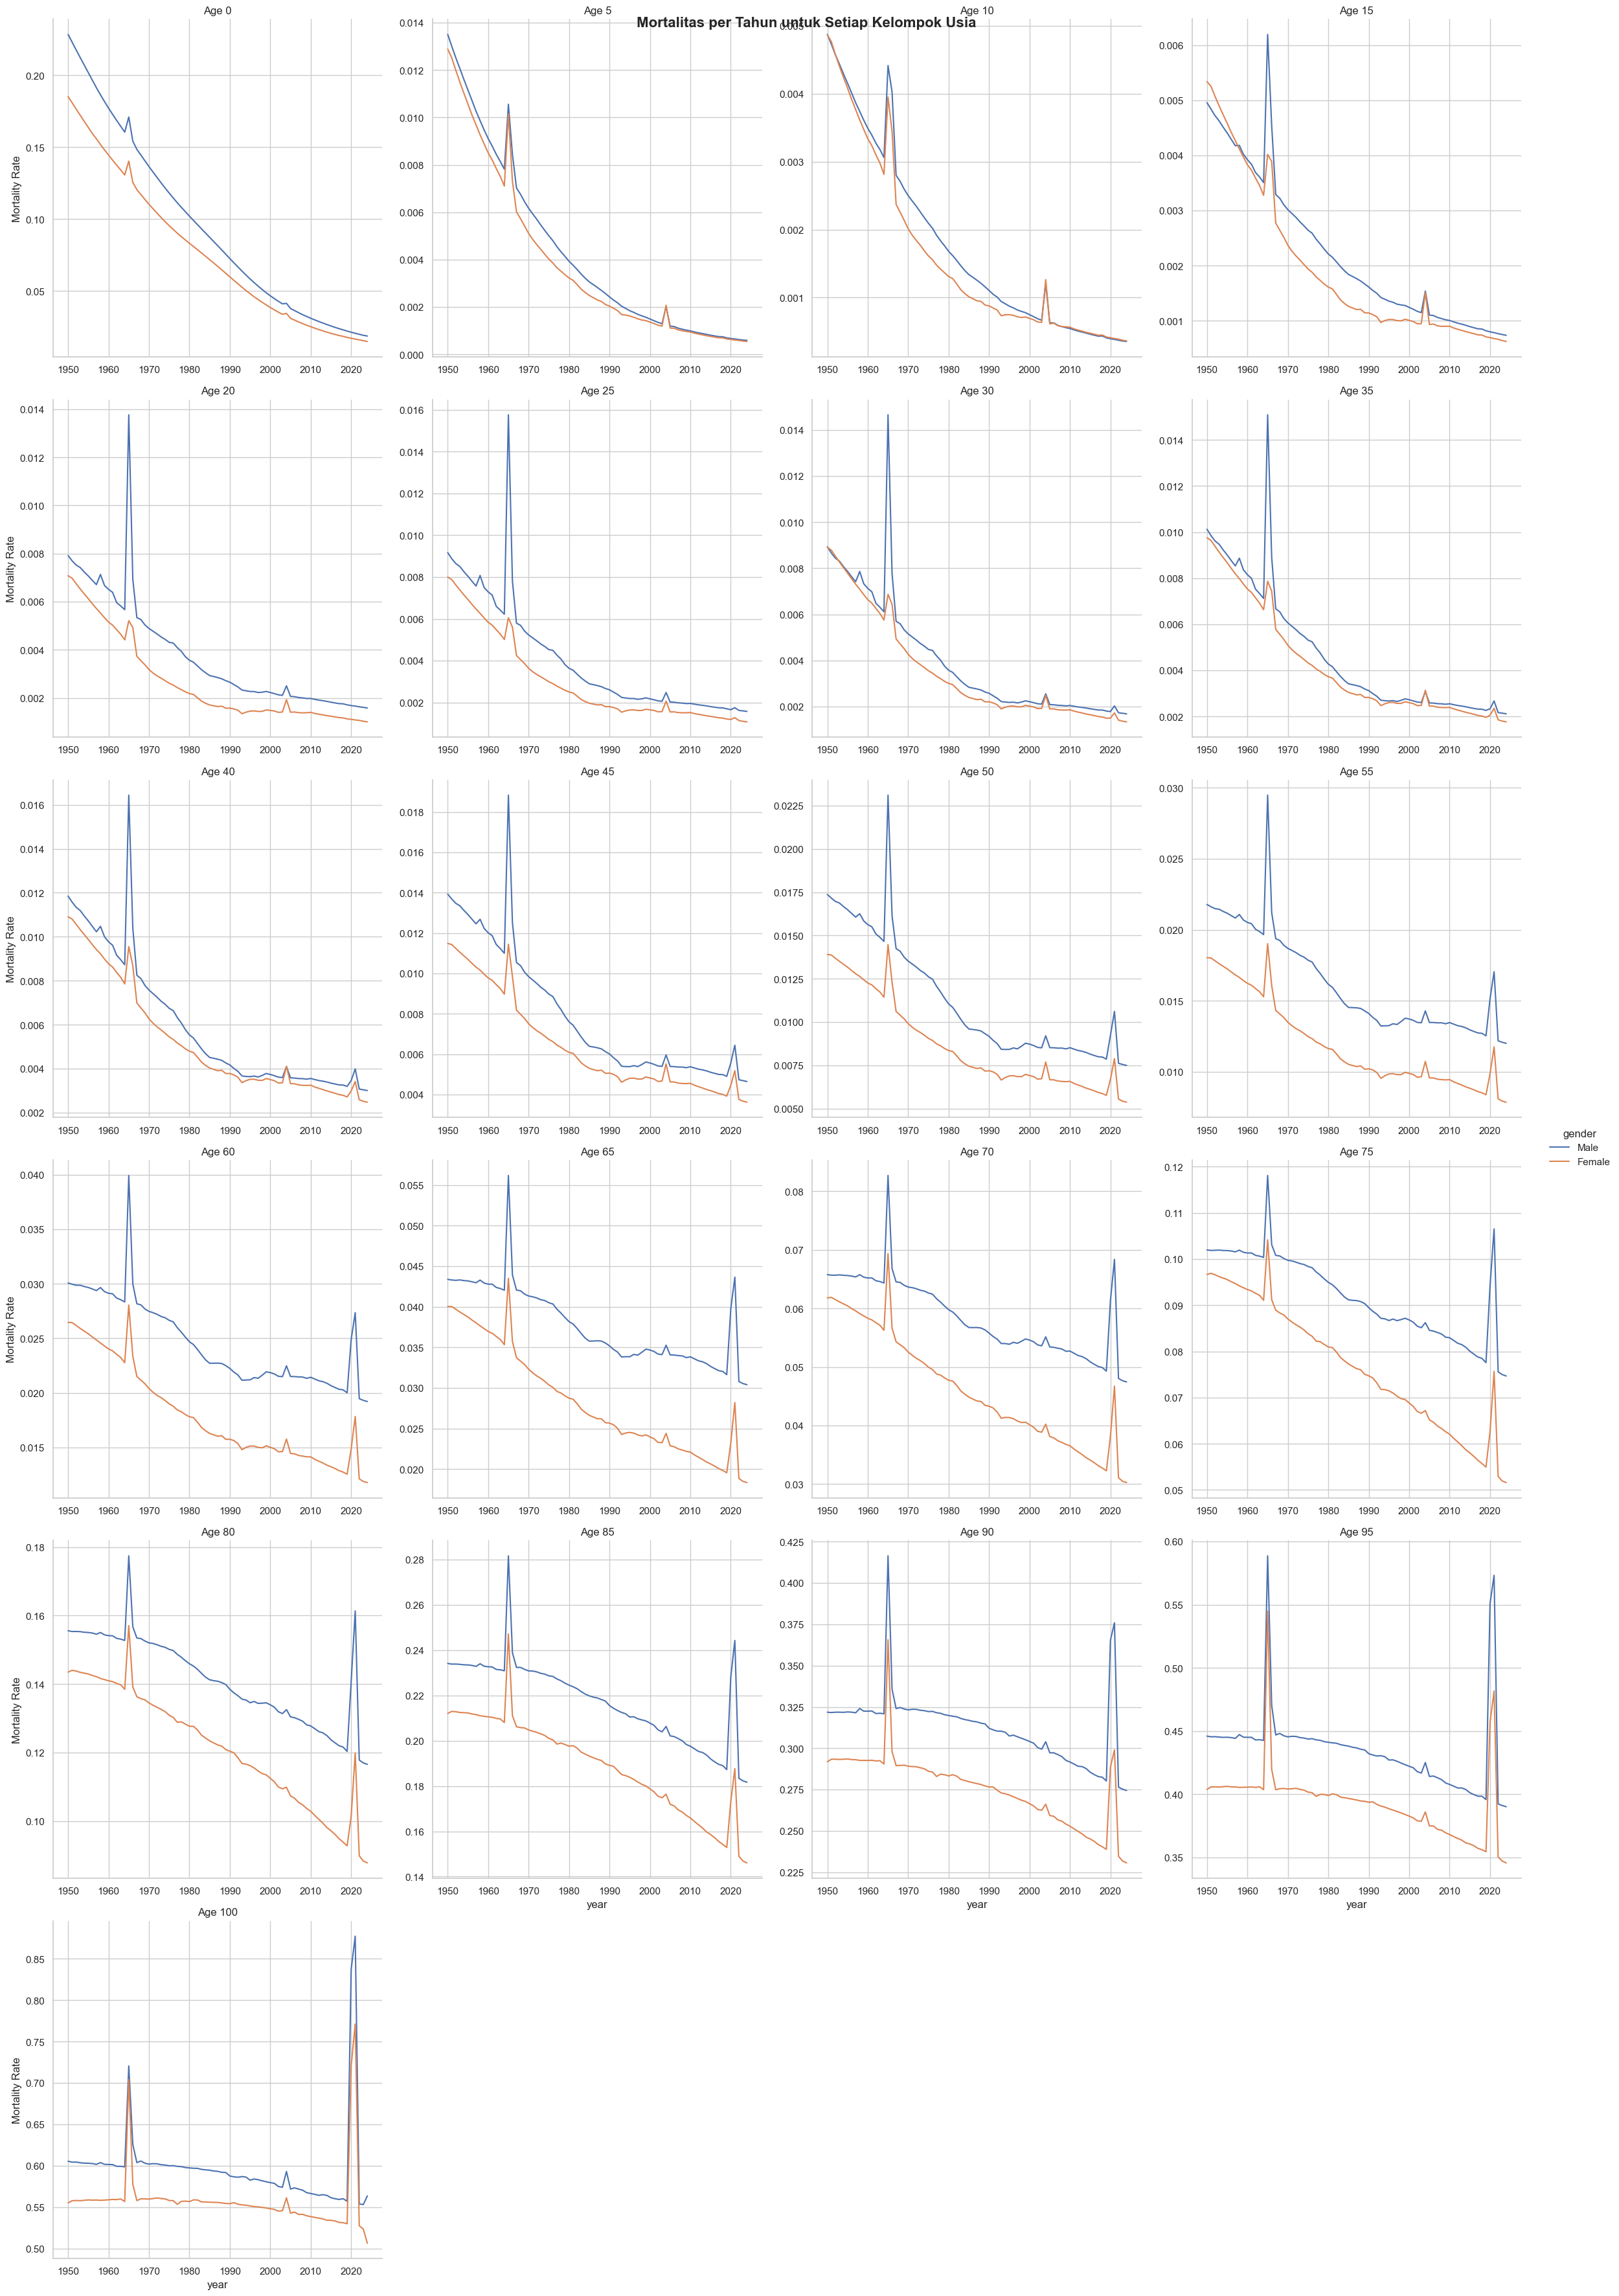

In [28]:
wrapper_plot_usia_vs_tahun(AGE_MIN, AGE_MAX)

## Plot mortalitas semua usia untuk satu tahun

In [29]:
from ta_module.utils import plot_tahun_vs_usia


def wrapper_plot_tahun_vs_usia(year_start: str, year_end: str):
    plot_tahun_vs_usia(
        mortalitas_df=mortalitas_df,
        age_col=AGE_COL,
        year_col=YEAR_COL,
        gender_col=GENDER_COL,
        mortality_col=MORTALITY_COL,
        year_start=year_start,
        year_end=year_end,
        plots_dir=plots_dir
    )

Plot tahun vs usia (1950-2024) saved to plots\tahun vs usia (1950-2024).png


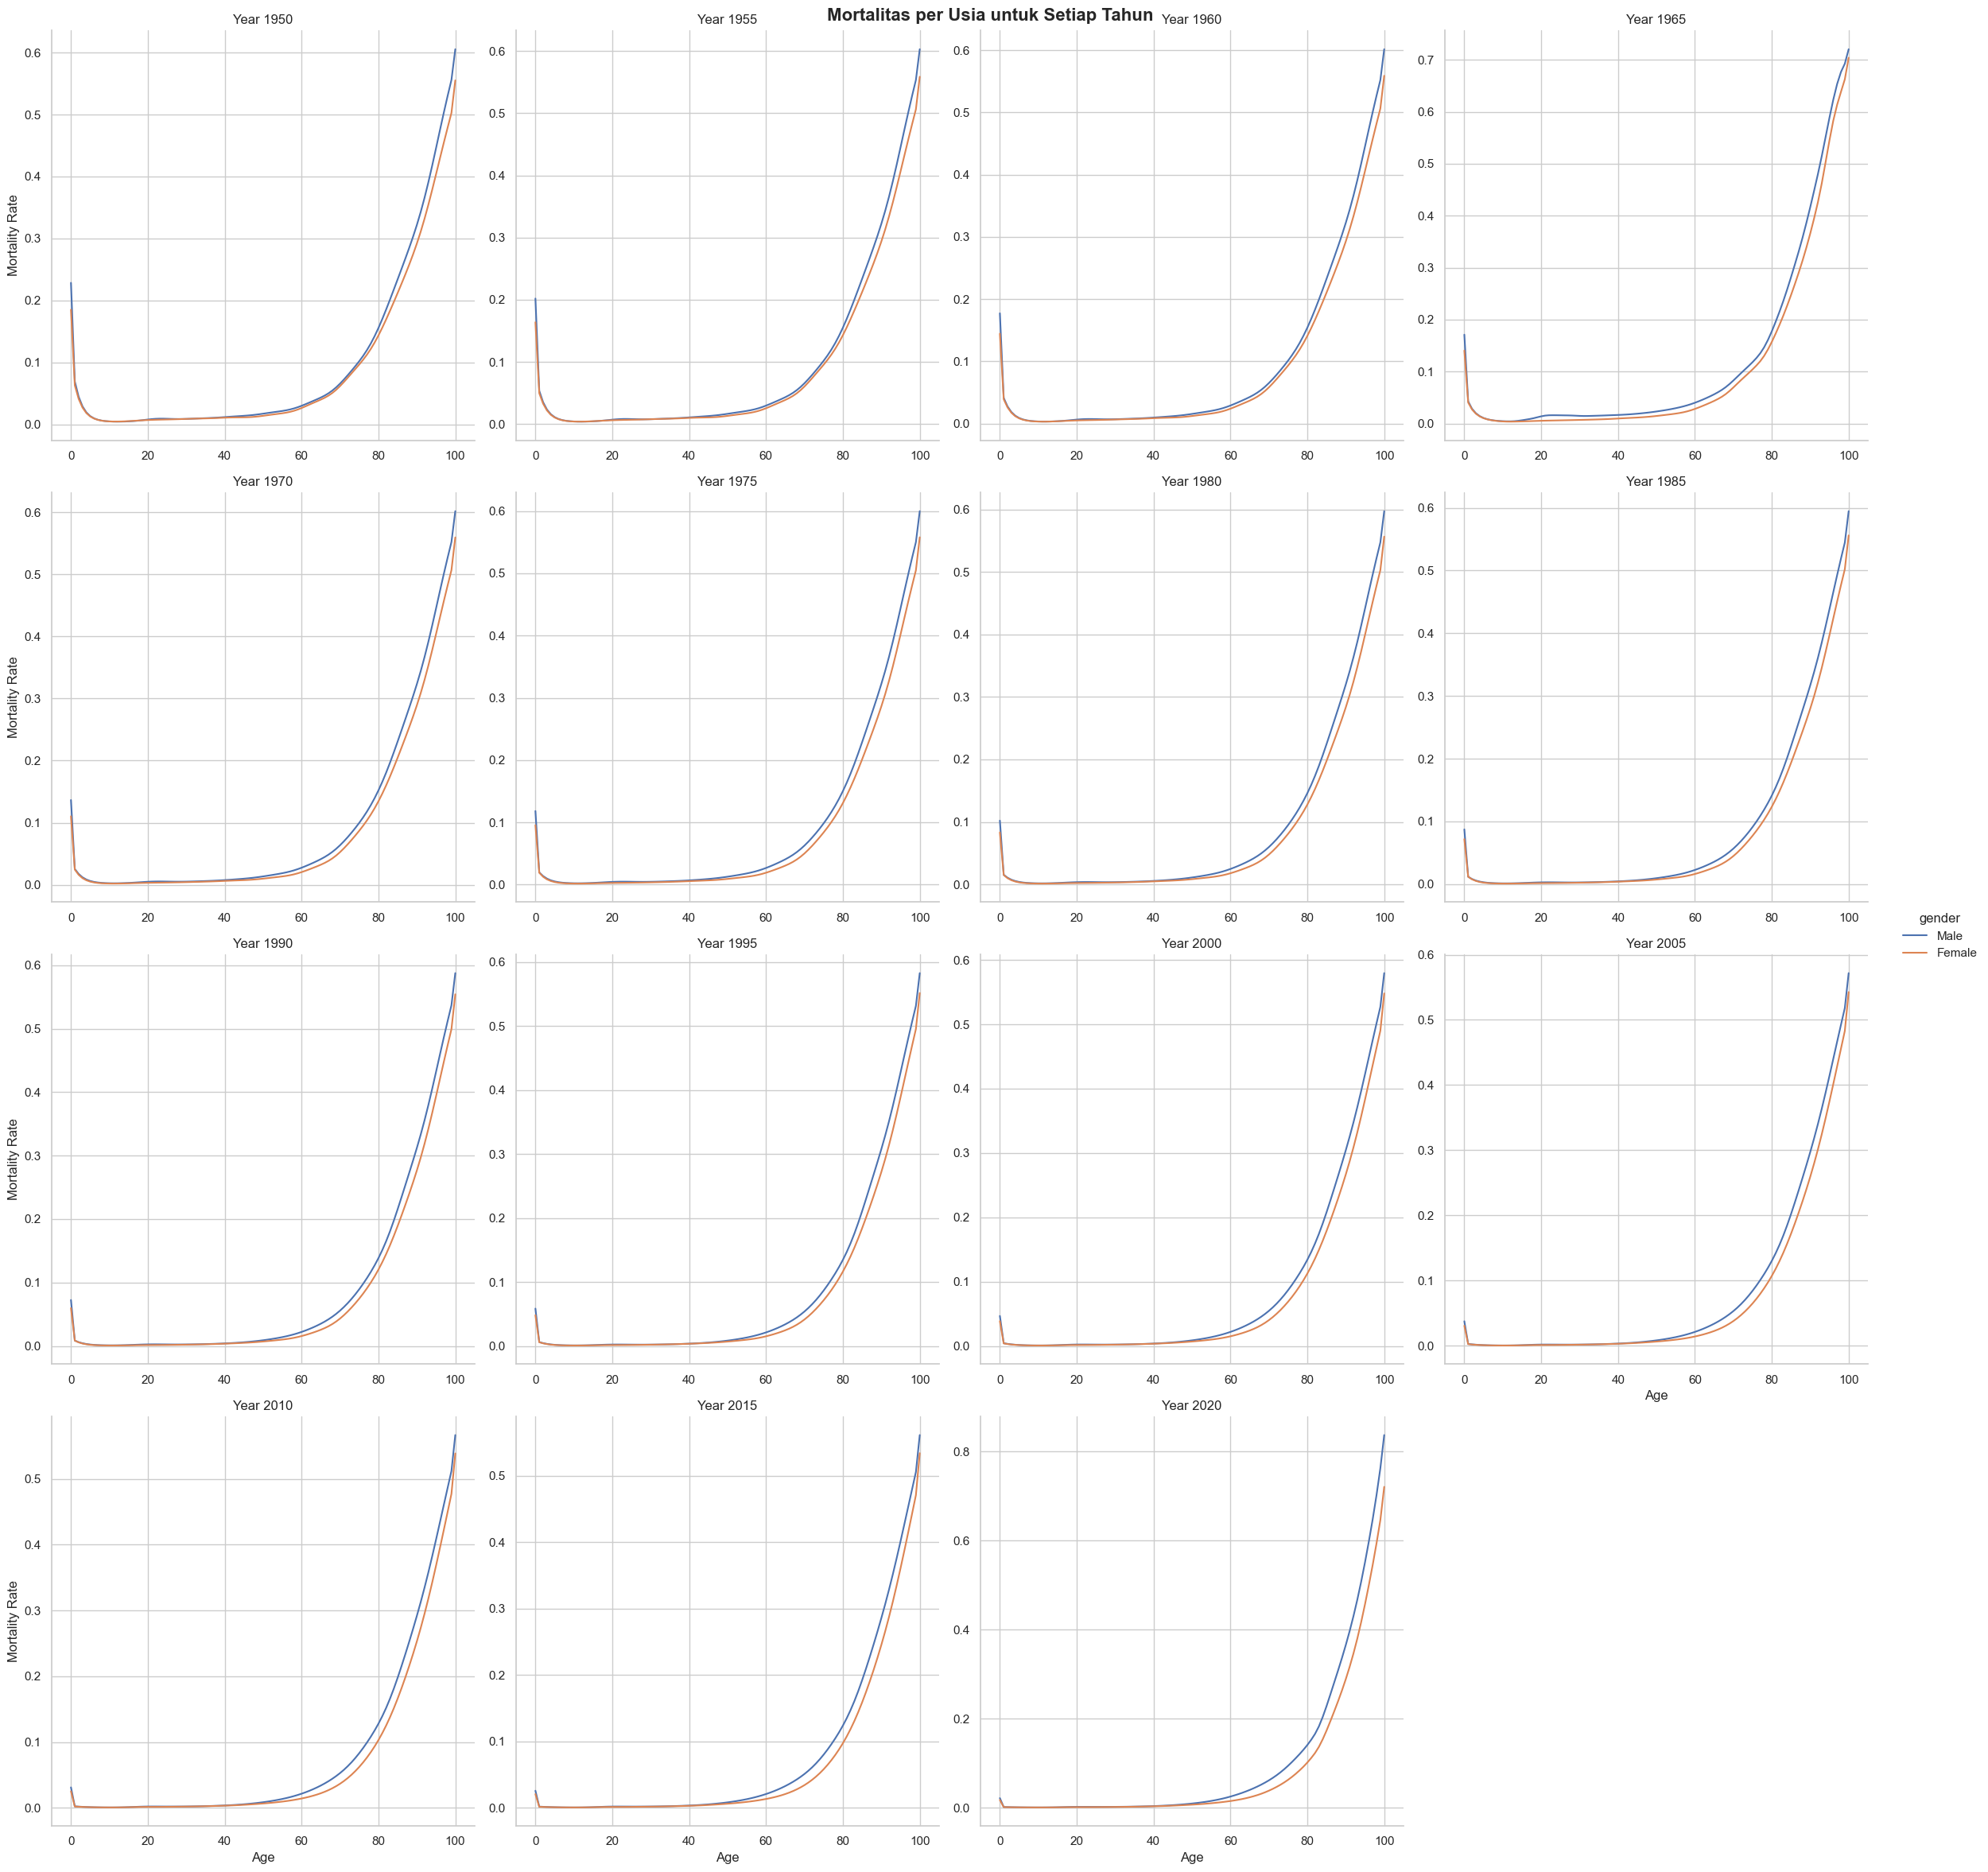

In [30]:
wrapper_plot_tahun_vs_usia(str(YEAR_MIN), str(YEAR_MAX))

# Persiapan data mortalitas untuk pelatihan model

## Transformasi data

In [31]:
from ta_module.utils import ScaledLogitTransform

# Dari persamaan asumsi UDD qx = 2mx / (2 + mx)
# 0 <= 1x <= 1
# Jadi constraint untuk mx adalah:
lower_bound = 0.0
upper_bound = 2.0
link_fn = ScaledLogitTransform(lb=lower_bound, ub=upper_bound)

transformed_M_male = link_fn(M_male)
transformed_M_female = link_fn(M_female)

In [32]:
pd.DataFrame(transformed_M_male.cpu().numpy()).to_csv(
    DOT_ENV.results_dir / "transformed_M_male.csv", sep=";", decimal=","
    )
pd.DataFrame(transformed_M_female.cpu().numpy()).to_csv(
    DOT_ENV.results_dir / "transformed_M_female.csv", sep=";", decimal=","
    )

In [33]:
TRAINING_CONFIG = CONFIG.training

## Pembagian data

In [34]:
from ta_module.data import get_train_val_test_split

train_split = CONFIG.split.train
val_split = CONFIG.split.validation
test_split = CONFIG.split.test

M_male_train, M_male_val, M_male_test = get_train_val_test_split(
    mortality_matrix=transformed_M_male,
    train_split=train_split,
    val_split=val_split,
    test_split=test_split
)

M_female_train, M_female_val, M_female_test = get_train_val_test_split(
    mortality_matrix=transformed_M_female,
    train_split=train_split,
    val_split=val_split,
    test_split=test_split
)

In [35]:
lookback = CONFIG.dataset.lookback
horizon = CONFIG.dataset.horizon

# Tambahkan konteks dari data train ke data val dan test agar sesuai dengan kebutuhan lookback
M_male_val_extend = torch.cat([M_male_train[-lookback:, :], M_male_val], dim=0)
M_male_test_extend = torch.cat([M_male_val_extend[-lookback:, :], M_male_test], dim=0)
M_female_val_extend = torch.cat([M_female_train[-lookback:, :], M_female_val], dim=0)
M_female_test_extend = torch.cat([M_female_val_extend[-lookback:, :], M_female_test], dim=0)

In [36]:
import torch
import numpy as np

from ta_module.data import NormalizedMortalityDataset

train_male_mean = M_male_train.mean(dim=0)
train_male_std = M_male_train.std(dim=0)

pd.DataFrame({"mean": train_male_mean.cpu().numpy(), "std": train_male_std.cpu().numpy()}).to_csv(
    DOT_ENV.results_dir / "train_male_mean_std.csv", sep=";", decimal=","
)

## Normalisasi data

### Laki-laki

In [37]:
create_male_dataset_split = NormalizedMortalityDataset.factory(
    lookback=lookback,
    horizon=horizon,
    mean=train_male_mean,
    std=train_male_std,
)

train_male_dataset = create_male_dataset_split(M_male_train)
val_male_dataset = create_male_dataset_split(M_male_val_extend)
test_male_dataset = create_male_dataset_split(M_male_test_extend)

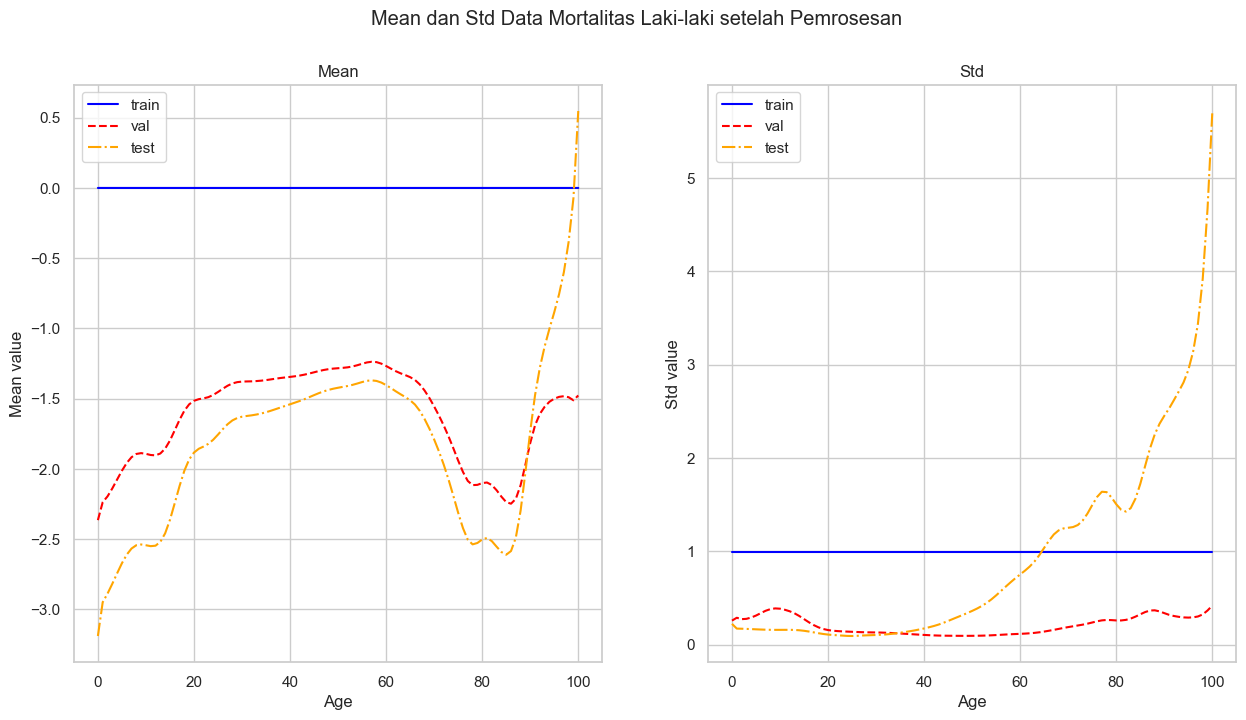

In [38]:
import matplotlib.pyplot as plt
from ta_module.utils import normalize

male_train_normalized = normalize(M_male_train, train_male_mean, train_male_std).cpu().numpy()
male_val_normalized = normalize(M_male_val, train_male_mean, train_male_std).cpu().numpy()
male_test_normalized = normalize(M_male_test, train_male_mean, train_male_std).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].plot(male_train_normalized.mean(axis=0), color="blue", linestyle="-", label="train")
ax[0].plot(male_val_normalized.mean(axis=0), color="red", linestyle="--", label="val")
ax[0].plot(male_test_normalized.mean(axis=0), color="orange", linestyle="-.", label="test")
ax[0].set_title("Mean")
ax[0].legend()
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Mean value")

ax[1].plot(male_train_normalized.std(axis=0), color="blue", linestyle="-", label="train")
ax[1].plot(male_val_normalized.std(axis=0), color="red", linestyle="--", label="val")
ax[1].plot(male_test_normalized.std(axis=0), color="orange", linestyle="-.", label="test")
ax[1].set_title("Std")
ax[1].legend()
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Std value")

fig.suptitle("Mean dan Std Data Mortalitas Laki-laki setelah Pemrosesan")
fig.savefig(DOT_ENV.plots_dir / "mean_std_mortalitas_laki-laki_setelah_pemrosesan.png")
plt.show()

### Perempuan

In [39]:
train_female_mean = M_female_train.mean(dim=0)
train_female_std = M_female_train.std(dim=0)

pd.DataFrame({"mean": train_female_mean.cpu().numpy(), "std": train_female_std.cpu().numpy()}).to_csv(
    DOT_ENV.results_dir / "train_female_mean_std.csv", sep=";", decimal=","
)

In [40]:
create_female_dataset_split = NormalizedMortalityDataset.factory(
    lookback=lookback,
    horizon=horizon,
    mean=train_female_mean,
    std=train_female_std,
)

train_female_dataset = create_female_dataset_split(M_female_train)
val_female_dataset = create_female_dataset_split(M_female_val_extend)
test_female_dataset = create_female_dataset_split(M_female_test_extend)

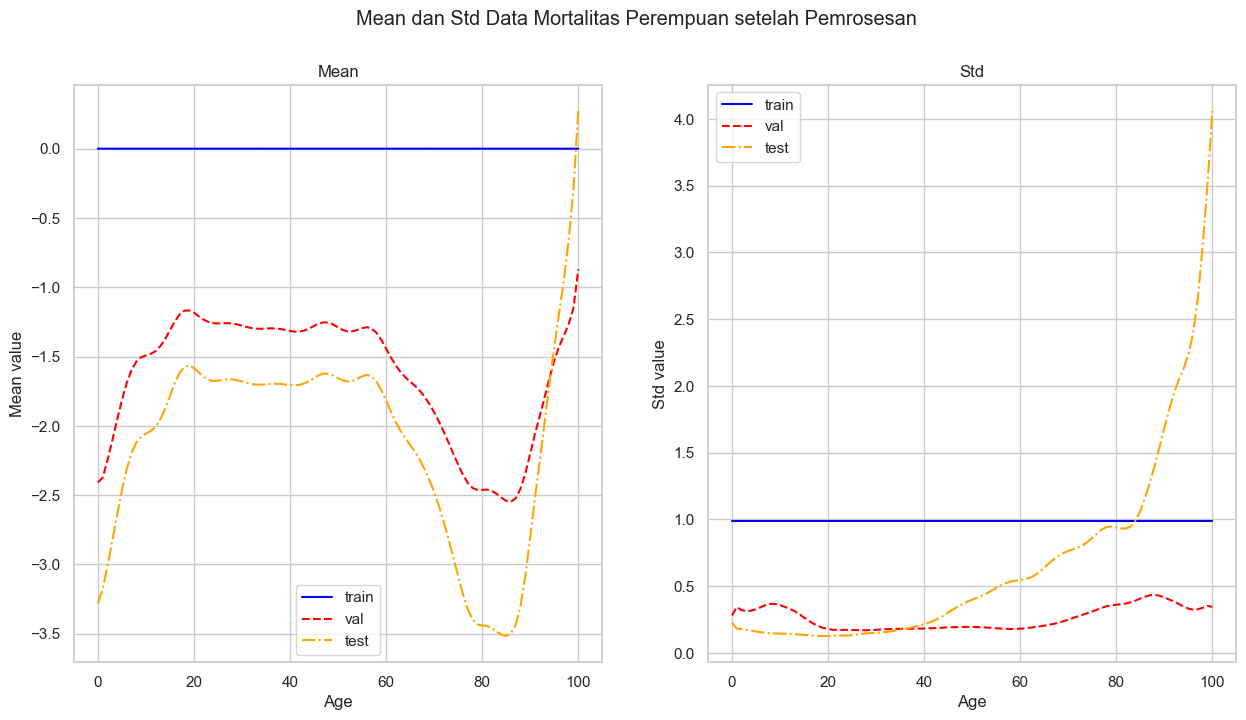

In [41]:
female_train_normalized = normalize(M_female_train, train_female_mean, train_female_std).cpu().numpy()
female_val_normalized = normalize(M_female_val, train_female_mean, train_female_std).cpu().numpy()
female_test_normalized = normalize(M_female_test, train_female_mean, train_female_std).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].plot(female_train_normalized.mean(axis=0), color="blue", linestyle="-", label="train")
ax[0].plot(female_val_normalized.mean(axis=0), color="red", linestyle="--", label="val")
ax[0].plot(female_test_normalized.mean(axis=0), color="orange", linestyle="-.", label="test")
ax[0].set_title("Mean")
ax[0].legend()
ax[0].set_xlabel("Age")
ax[0].set_ylabel("Mean value")

ax[1].plot(female_train_normalized.std(axis=0), color="blue", linestyle="-", label="train")
ax[1].plot(female_val_normalized.std(axis=0), color="red", linestyle="--", label="val")
ax[1].plot(female_test_normalized.std(axis=0), color="orange", linestyle="-.", label="test")
ax[1].set_title("Std")
ax[1].legend()
ax[1].set_xlabel("Age")
ax[1].set_ylabel("Std value")

fig.suptitle("Mean dan Std Data Mortalitas Perempuan setelah Pemrosesan")
fig.savefig(DOT_ENV.plots_dir / "mean_std_mortalitas_perempuan_setelah_pemrosesan.png")
plt.show()

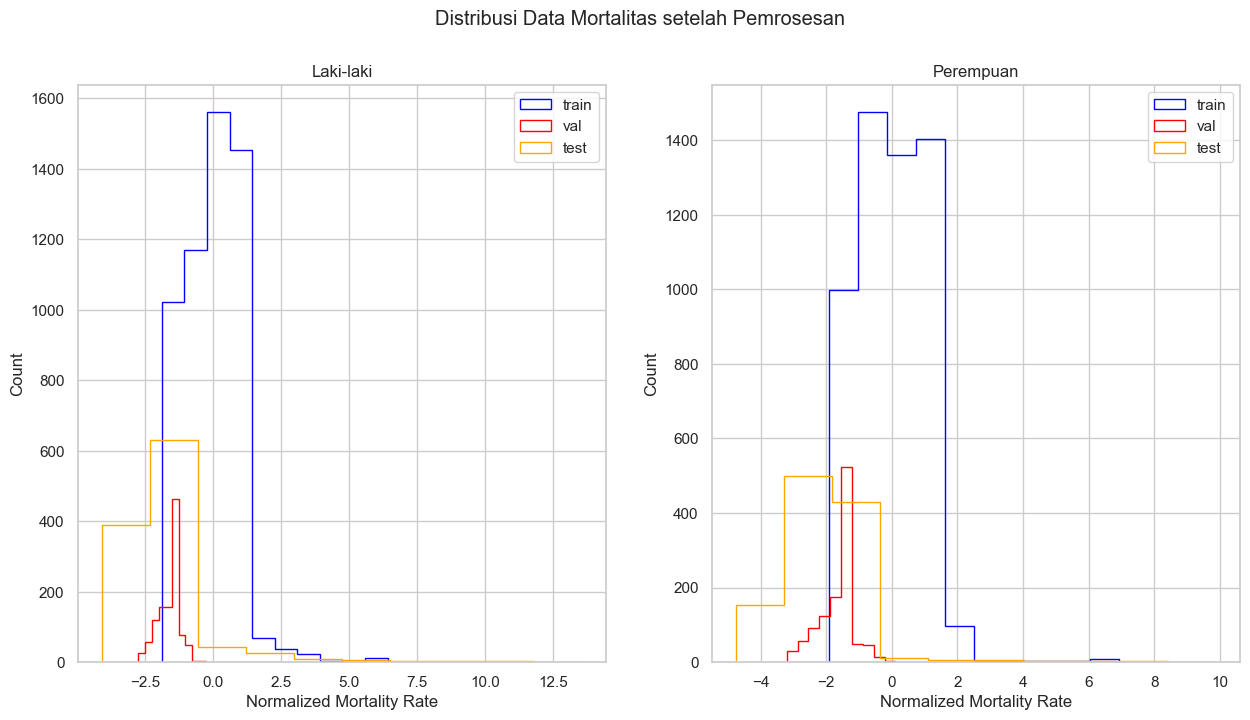

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(15, 7.5))
ax[0].hist(male_train_normalized.reshape(-1), color="blue", histtype="step", label="train")
ax[0].hist(male_val_normalized.reshape(-1), color="red", histtype="step", label="val")
ax[0].hist(male_test_normalized.reshape(-1), color="orange", histtype="step", label="test")
ax[0].legend()
ax[0].set_title("Laki-laki")
ax[0].set_xlabel("Normalized Mortality Rate")
ax[0].set_ylabel("Count")

ax[1].hist(female_train_normalized.reshape(-1), color="blue", histtype="step", label="train")
ax[1].hist(female_val_normalized.reshape(-1), color="red", histtype="step", label="val")
ax[1].hist(female_test_normalized.reshape(-1), color="orange", histtype="step", label="test")
ax[1].legend()
ax[1].set_title("Perempuan")
ax[1].set_xlabel("Normalized Mortality Rate")
ax[1].set_ylabel("Count")

fig.suptitle("Distribusi Data Mortalitas setelah Pemrosesan")
fig.savefig(DOT_ENV.plots_dir / "distribusi_data_mortalitas_setelah_pemrosesan.png")
plt.show()

## Penggabungan data mortalitas laki-laki dan perempuan untuk pelatihan

In [43]:
from torch.utils.data import ConcatDataset

train_dataset = ConcatDataset([train_male_dataset, train_female_dataset])
val_dataset = ConcatDataset([val_male_dataset, val_female_dataset])

In [44]:
from torch.utils.data import DataLoader

batch_size = TRAINING_CONFIG.batch_size

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)

# Pelatihan model

## Definisi arsitektur model

In [45]:
MODEL_CONFIG = CONFIG.model

### LCN

In [46]:
from torch import nn
from ta_module.models import LocalGLMnet, LocallyConnected2D

ukuran_matriks_input = (lookback, AGE_MAX - AGE_MIN + 1)
lcn_activation_function = nn.Sigmoid()
LCN_CONFIG = MODEL_CONFIG.lcn

create_lcn_layer = LocallyConnected2D.factory(
    input_size=ukuran_matriks_input,
    activation_fn=lcn_activation_function,
    kernel_size=LCN_CONFIG.kernel_size,
    zero_padding=LCN_CONFIG.zero_padding,
    bias=LCN_CONFIG.bias,
)

### LocalGLMnet

In [47]:
LOCALGLMNET_CONFIG = MODEL_CONFIG.localglmnet
create_localglmnet_model = LocalGLMnet.factory(
    input_size=ukuran_matriks_input,
    bias=LOCALGLMNET_CONFIG.bias,
)

## Definisi metode pelatihan model

In [48]:
TRAINING_CONFIG = CONFIG.training

### Loss function dan metrik evaluasi

In [49]:
import torch.nn.functional as F

loss_metric_fn = F.mse_loss
eval_metric_fn = F.l1_loss

### Optimizer dan lr scheduler

In [50]:
from typing import Iterator
from torch.optim import NAdam

OPTIMIZER_CONFIG = TRAINING_CONFIG.optimizer


def create_optimizer(params: Iterator[nn.Parameter]):
    return NAdam(
        params=params,
        lr=OPTIMIZER_CONFIG.lr,
    )

In [51]:
from torch.optim import Optimizer
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingWarmRestarts, SequentialLR

LR_SCHEDULER_CONFIG = TRAINING_CONFIG.lr_scheduler


def create_lr_scheduler(optimizer: Optimizer):
    warm_up_epochs = LR_SCHEDULER_CONFIG.total_iters
    warm_up_scheduler = LinearLR(
        optimizer=optimizer,
        start_factor=LR_SCHEDULER_CONFIG.start_factor,
        end_factor=LR_SCHEDULER_CONFIG.end_factor,
        total_iters=warm_up_epochs
    )

    sgdr_scheduler = CosineAnnealingWarmRestarts(
        optimizer=optimizer,
        T_0=LR_SCHEDULER_CONFIG.T_0,
        T_mult=LR_SCHEDULER_CONFIG.T_mult,
        eta_min=LR_SCHEDULER_CONFIG.eta_min
    )

    return SequentialLR(
        optimizer=optimizer,
        schedulers=[warm_up_scheduler, sgdr_scheduler],
        milestones=[warm_up_epochs]
    )

## Grid search untuk hyperparameter koefisien regularisasi LASSO

In [52]:
TUNING_CONFIG = CONFIG.tuning

In [53]:
from optuna.trial import Trial
from typing import Callable, Iterator
from torch.nn import Parameter

from ta_module.tuning import reg_coef_grid_search, reg_coef_objective
from ta_module.config import TuneMetadata, ModeEnum
from ta_module.utils import get_current_run_datetime, ElasticNetRegularizationTerm

if CONFIG.mode == ModeEnum.TUNE:
    max_epochs = TRAINING_CONFIG.max_epochs
    min_epochs = TRAINING_CONFIG.min_epochs
    reg_coef_candidates = TUNING_CONFIG.reg_coef_candidates


    def create_mymodel_with_reg_coef(
        reg_coef: float
    ):
        def _create_regularization_term(model_weights_getter: Callable[[], Iterator[Parameter]]):
            return ElasticNetRegularizationTerm(
                reg_coef=reg_coef,
                alpha=TRAINING_CONFIG.regularization.alpha,
                model_weights_getter=model_weights_getter,
            )

        localglmnet = create_localglmnet_model(create_lcn_layer())
        localglmnet_attention_weights_getter = lambda: (
            params for name, params in
            localglmnet.regression_attention_model.named_parameters()
            if "bias" not in name
        )

        return MyModel(
            model=localglmnet,
            loss_metric=loss_metric_fn,
            eval_metric=eval_metric_fn,
            create_optimizer=create_optimizer,
            create_lr_scheduler=create_lr_scheduler,
            regularization_term=_create_regularization_term(model_weights_getter=localglmnet_attention_weights_getter),
        )


    objective: Callable[[Trial], float] = lambda trial: (
        reg_coef_objective(
            trial=trial,
            create_my_model_with_reg_coef=create_mymodel_with_reg_coef,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            max_epochs=max_epochs,
            min_epochs=min_epochs,
            log_dir=DOT_ENV.tuning_logs_dir,
            checkpoint_dir=DOT_ENV.tuning_checkpoints_dir,
            reg_coef_candidates=reg_coef_candidates,
            gradient_clip_val=TRAINING_CONFIG.regularization.gradient_clip_val
        )
    )

    run_datetime = get_current_run_datetime()
    print(f"==================================================================")
    print("Mulai grid search untuk hyperparameter reg_coef dalam lasso loss")
    print(f"Run datetime: {run_datetime}")
    print(f"reg_coef candidates: {reg_coef_candidates}")
    print(f"==================================================================\n")
    grid_search_result = reg_coef_grid_search(
        objective_fn=objective,
        reg_coef_candidates=reg_coef_candidates,
        storage=DOT_ENV.optuna_db_url,
        seed=CONFIG.seed,
    )
    print(f"\n==================================================================\n")
    print("Grid_search selesai!")
    print(f"Result:\n{grid_search_result}\n")

    last_tune_metadata_filepath = DOT_ENV.last_tune_metadata_file
    print(f"Update file {last_tune_metadata_filepath}:")
    tune_metadata: TuneMetadata = TuneMetadata.model_validate(
        {
            "datetime": run_datetime,
            "result"  : grid_search_result,
        }
    )
    print(f"Tune metadata:\n{tune_metadata}\n")
    with open(last_tune_metadata_filepath, "w") as f:
        f.write(tune_metadata.model_dump_json(indent=4))
    print(f"Update berhasil!")
else:
    print(f"Mode = {CONFIG.mode}")
    print("Skip proses tuning")

Mode = inference
Skip proses tuning


## Pelatihan model dengan hyperparameter terbaik

### Load hyperparameter terbaik dari tune metadata

In [54]:
from ta_module.config import load_last_tune_metadata

last_tune_metadata = load_last_tune_metadata(DOT_ENV.last_tune_metadata_file)
print(f"Last tune metadata:\n{last_tune_metadata}")

Last tune metadata:
datetime=datetime.datetime(2026, 4, 23, 15, 29, 44, 715716, tzinfo=TzInfo(25200)) result=TuningResult(study_name='reg_coef_grid_search_2026-04-23_15-29-44', trials={'number': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9], 'value': [0.05647346004843712, 0.0998634323477745, 0.04028022289276123, 0.12678010761737823, 0.0610501728951931, 0.0886676236987114, 0.12594616413116455, 0.09278502315282822, 0.12007259577512741, 0.051128312945365906], 'datetime_start': ['2026-04-23T08:29:45.342481', '2026-04-23T08:33:20.988938', '2026-04-23T08:36:48.615520', '2026-04-23T08:40:18.567076', '2026-04-23T08:43:43.297196', '2026-04-23T08:47:15.450694', '2026-04-23T08:50:41.734629', '2026-04-23T08:54:09.554197', '2026-04-23T08:57:37.689111', '2026-04-23T09:01:03.339998'], 'datetime_complete': ['2026-04-23T08:33:20.913471', '2026-04-23T08:36:48.569276', '2026-04-23T08:40:18.496908', '2026-04-23T08:43:43.246680', '2026-04-23T08:47:15.402219', '2026-04-23T08:50:41.676897', '2026-04-23T08:54:09.504733', '2

In [55]:
tune_trials_result = pd.DataFrame(last_tune_metadata.result.trials)
tune_trials_result.to_csv(DOT_ENV.results_dir / "tune_trials_result.csv", sep=";", decimal=",")

In [56]:
best_reg_coef = last_tune_metadata.result.best_params.get("reg_coef", None)
create_elasticnet_regularization = ElasticNetRegularizationTerm.factory(
    reg_coef=best_reg_coef,
    alpha=TRAINING_CONFIG.regularization.alpha,
)

### Proses pelatihan

In [57]:
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import TensorBoardLogger, CSVLogger
from lightning import Trainer

from ta_module.config import TrainMetadata
from ta_module.models import MyModel
from ta_module.utils import get_current_run_datetime_str

if CONFIG.mode in [ModeEnum.TRAIN, ModeEnum.TUNE]:
    num_ensembles = MODEL_CONFIG.num_ensembles
    localglmnet_models = [
        create_localglmnet_model(create_lcn_layer())

        for _ in range(num_ensembles)
    ]

    localglmnet_attention_weight_getters = [
        lambda: (params for name, params in localglmnet.regression_attention_model.named_parameters() if
                 "bias" not in name)
        for localglmnet in localglmnet_models
    ]

    logalglmnet_mymodels = [
        MyModel(
            model=localglmnet_models[i],
            loss_metric=loss_metric_fn,
            eval_metric=eval_metric_fn,
            regularization_term=create_elasticnet_regularization(localglmnet_attention_weight_getters[i]),
            create_optimizer=create_optimizer,
            create_lr_scheduler=create_lr_scheduler
        )

        for i in range(num_ensembles)
    ]

    max_epochs = TRAINING_CONFIG.max_epochs
    min_epochs = TRAINING_CONFIG.min_epochs
    run_datetime = get_current_run_datetime()
    run_datetime_str = get_current_run_datetime_str()
    model_names = [f"LocalGLMnet_{i + 1}" for i in range(num_ensembles)]
    checkpoint_dirs = [DOT_ENV.training_checkpoints_dir / model_names[i] for i in range(num_ensembles)]

    trainers = [
        Trainer(
            max_epochs=max_epochs,
            min_epochs=min_epochs,
            log_every_n_steps=1,
            deterministic=True,
            gradient_clip_val=TRAINING_CONFIG.regularization.gradient_clip_val,
            logger=[
                TensorBoardLogger(
                    save_dir=DOT_ENV.training_logs_dir,
                    name=model_names[i],
                    version=run_datetime_str
                ),
                CSVLogger(
                    save_dir=DOT_ENV.training_logs_dir,
                    name=model_names[i],
                    version=run_datetime_str,
                )
            ],
            callbacks=[
                ModelCheckpoint(
                    dirpath=checkpoint_dirs[i],
                    filename=run_datetime_str,
                    monitor="val_loss",
                    mode="min",
                    save_top_k=1
                )
            ]
        )

        for i in range(num_ensembles)
    ]

    # Train ensembles pada data mortalitas laki-laki dan perempuan
    print(f"Melatih {num_ensembles} model LocalGLMnet secara independen")
    print(f"Run datetime: {run_datetime_str}")
    for i, (trainer, model) in enumerate(zip(trainers, logalglmnet_mymodels)):
        print("\n================================================================")
        print(f"Training model {i + 1} pada mortalitas laki-laki dan perempuan:")
        print("================================================================\n")
        trainer.fit(
            model=model,
            train_dataloaders=train_dataloader,
            val_dataloaders=val_dataloader,
        )

    print("Pelatihan selesai!")

    # Save metadadata
    last_train_metadata_filepath = DOT_ENV.last_train_metadata_file
    checkpoint_file_paths = [checkpoint_dirs[i] / f"{run_datetime_str}.ckpt" for i in range(num_ensembles)]
    print(f"Update file {last_train_metadata_filepath}:")
    # metadata digunakan untuk load checkpoint model terakhir secara otomatis
    # jika tidak run proses pelatihan
    train_metadata = TrainMetadata.model_validate(
        {
            "datetime"             : run_datetime,
            "checkpoint_file_paths": checkpoint_file_paths,
        }, extra="forbid"
    )
    print(f"Train metadata:\n{train_metadata}\n")
    with open(last_train_metadata_filepath, "w") as f:
        f.write(train_metadata.model_dump_json(indent=4))
    print("Update berhasil!")
else:
    print(f"Mode = {CONFIG.mode}")
    print("Skip proses pelatihan, langsung inference")

Mode = inference
Skip proses pelatihan, langsung inference


# Evaluasi model LocalGLMnet

In [58]:
from ta_module.config import load_last_train_metadata

last_train_metadata = load_last_train_metadata(DOT_ENV.last_train_metadata_file)

In [59]:
last_train_metadata

TrainMetadata(datetime=datetime.datetime(2026, 4, 23, 16, 4, 28, 139166, tzinfo=TzInfo(25200)), checkpoint_file_paths=[WindowsPath('checkpoints/training/LocalGLMnet_1/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_2/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_3/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_4/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_5/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_6/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_7/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_8/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_9/2026-04-23_16-04-28.ckpt'), WindowsPath('checkpoints/training/LocalGLMnet_10/2026-04-23_16-04-28.ckpt')])

In [60]:
localglmnet_models = []
for checkpoint_filepath in last_train_metadata.checkpoint_file_paths:
    localglmnet_model = create_localglmnet_model(create_lcn_layer())
    ckpt = torch.load(checkpoint_filepath, map_location=DEVICE)
    state_dict = ckpt["state_dict"]

    # sesuaikan dengan nama atribut di LightningModule-mu
    prefix = "model."
    state_dict = {
        k[len(prefix):]: v
        for k, v in state_dict.items()
        if k.startswith(prefix)
    }

    localglmnet_model.load_state_dict(state_dict)
    localglmnet_model.eval()
    localglmnet_models.append(localglmnet_model)

print(localglmnet_models)

[LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (activation_fn): Sigmoid()
  )
), LocalGLMnet(
  (regression_attention_model): LocallyConnected2D(
    (ac

In [61]:
from ta_module.models import EnsembleLocalGLMNet

localglmnet_ensemble = EnsembleLocalGLMNet(
    models=localglmnet_models,
).to(DEVICE)

print(localglmnet_ensemble)

EnsembleLocalGLMNet(
  (models): ModuleList(
    (0-9): 10 x LocalGLMnet(
      (regression_attention_model): LocallyConnected2D(
        (activation_fn): Sigmoid()
      )
    )
  )
)


In [62]:
from ta_module.utils import denormalize

test_male_dataloader = DataLoader(test_male_dataset, batch_size=len(test_male_dataset), shuffle=False)
male_test_loss = 0.0
male_test_score = 0.0

for batch in test_male_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)

    y_detransformed = link_fn.inv(denormalize(y, train_male_mean, train_male_std))
    y_pred_detransformed = link_fn.inv(denormalize(y_pred, train_male_mean, train_male_std))

    male_test_loss = F.mse_loss(y_detransformed, y_pred_detransformed).detach()
    male_test_score = F.l1_loss(y_detransformed, y_pred_detransformed).detach()

print(f"Male test MSE = {male_test_loss:.6f}")
print(f"Male test MAE = {male_test_score:.6f}")

Male test MSE = 0.001685
Male test MAE = 0.013423


In [63]:
test_female_dataloader = DataLoader(test_female_dataset, batch_size=len(test_male_dataset), shuffle=False)
female_test_loss = 0.0
female_test_score = 0.0

for batch in test_female_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)

    y_detransformed = link_fn.inv(denormalize(y, train_female_mean, train_female_std))
    y_pred_detransformed = link_fn.inv(denormalize(y_pred, train_female_mean, train_female_std))

    female_test_loss = F.mse_loss(y_detransformed, y_pred_detransformed).detach()
    female_test_score = F.l1_loss(y_detransformed, y_pred_detransformed).detach()

print(f"Female test MSE = {female_test_loss:.6f}")
print(f"Female test MAE = {female_test_score:.6f}")

Female test MSE = 0.001099
Female test MAE = 0.011275


In [64]:
print(f"Average MSE = {(male_test_loss + female_test_loss) / 2:.6f}")
print(f"Average MAE = {(male_test_score + female_test_score) / 2:.6f}")

Average MSE = 0.001392
Average MAE = 0.012349


# Interpretasi pemodelan

In [65]:
# TODO

# Simulasi peramalan mortalitas

## Laki-laki

In [66]:
from ta_module.utils import denormalize

male_residuals = None
male_data_pred = None

male_dataloader = DataLoader(train_male_dataset, batch_size=len(train_male_dataset), shuffle=False)
for batch in male_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)
    male_residuals = y - y_pred
    male_data_pred = y_pred

male_data_pred = link_fn.inv(denormalize(male_data_pred, train_male_mean, train_male_std))
male_data_pred = male_data_pred.squeeze(1)

print(male_residuals[0])
print(male_residuals.shape)

print(male_data_pred[0])
print(male_data_pred.shape)

tensor([[ 1.4308e-02,  8.4162e-03,  2.0138e-02,  1.8580e-02,  6.7910e-03,
         -4.6930e-03, -1.3260e-02, -1.8609e-02, -2.0667e-02, -2.0890e-02,
         -1.8694e-02, -1.7664e-02, -1.9932e-02, -2.3964e-02, -2.8375e-02,
         -2.5866e-02, -1.8807e-02, -1.0175e-02, -4.4693e-03,  1.9616e-04,
          1.6122e-03,  9.3997e-04, -9.8002e-04, -2.4313e-03, -4.1542e-03,
         -4.2884e-03, -4.9238e-03, -4.4138e-03, -5.7107e-03, -6.6659e-03,
         -7.6028e-03, -9.8171e-03, -1.0350e-02, -1.2518e-02, -1.3467e-02,
         -1.5296e-02, -1.6826e-02, -1.8644e-02, -2.0203e-02, -2.2949e-02,
         -2.4686e-02, -2.7091e-02, -2.8118e-02, -3.0460e-02, -3.2541e-02,
         -3.3588e-02, -3.4347e-02, -3.3071e-02, -3.2499e-02, -3.1365e-02,
         -3.0121e-02, -2.8485e-02, -2.6415e-02, -2.5141e-02, -2.0271e-02,
         -1.2597e-02,  1.4759e-03,  1.4479e-02,  2.3656e-02,  2.7268e-02,
          3.1879e-02,  3.0961e-02,  3.6326e-02,  3.4951e-02,  4.2831e-02,
          5.0053e-02,  6.1916e-02,  6.

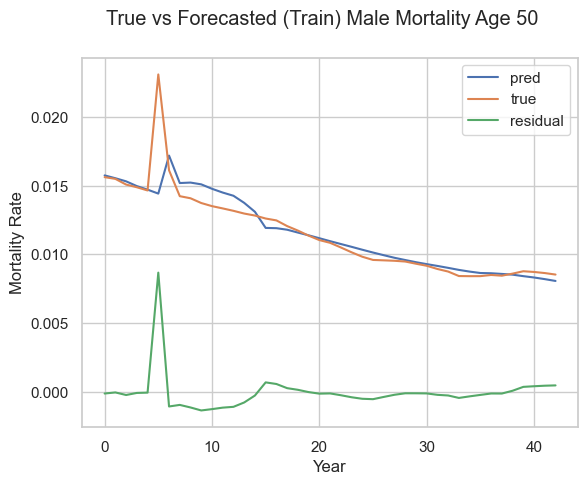

In [67]:
from math import ceil

age = 50
train_size = ceil(train_split * M_male.shape[0])

plt.plot(male_data_pred[:, age].cpu().numpy(), label="pred")
plt.plot(M_male[10:train_size, age].cpu().numpy(), label="true")
plt.plot((M_male[10:train_size, age] - male_data_pred[:, age]).cpu().numpy(), label="residual")

plt.legend()

plt.suptitle(f"True vs Forecasted (Train) Male Mortality Age {age}")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.show()

In [68]:
from ta_module.utils import recursive_forecast_with_residual_bootstrap, denormalize

male_simulations_file_path = DOT_ENV.results_dir / "male_mortality_simulations.pt"
if not male_simulations_file_path.exists():
    x, y = test_male_dataset[-1]
    # Dimensi = (10, W)
    x_in = torch.cat([x[1:, :], y])

    # Ubah menjadi dimensi = (1, 10, W)
    x_in = x_in.unsqueeze(0)

    print("=" * 100)
    print(f"Start recursive forecast with residual bootstrap for male mortality:")
    print("=" * 100)
    male_mortality_simulations = recursive_forecast_with_residual_bootstrap(
        model=localglmnet_ensemble,
        x=x_in,
        residuals=male_residuals,
        forecast_horizon=56,
        n_sim=10_000,
    )
    print("=" * 100)
    print(f"Simulation done!")
    print("=" * 100)
    # Denormalize
    print("Start denormalizing...")
    male_mortality_simulations = denormalize(male_mortality_simulations, train_male_mean, train_male_std)
    # Transformasi rentang nilai: R -> (0, 2)
    print("Start inverse link function transformation...")
    male_mortality_simulations = link_fn.inv(male_mortality_simulations)
    print(f"Save simulations to {male_simulations_file_path}")
    torch.save(obj=male_mortality_simulations, f=male_simulations_file_path)
    print("All done!")
else:
    male_mortality_simulations = torch.load(male_simulations_file_path, map_location=DEVICE)

print(male_mortality_simulations[0])
print(male_mortality_simulations.shape)

tensor([[4.9262e-03, 1.3564e-04, 1.5833e-04,  ..., 3.5687e-01, 3.8724e-01,
         4.5938e-01],
        [5.6569e-03, 1.8481e-04, 2.1934e-04,  ..., 3.7215e-01, 4.0742e-01,
         4.7366e-01],
        [6.1305e-03, 2.2534e-04, 2.7797e-04,  ..., 2.5884e-01, 2.8641e-01,
         3.3569e-01],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])
torch.Size([10000, 56, 101])


## Perempuan

In [69]:
female_residuals = None
female_data_pred = None

female_dataloader = DataLoader(train_female_dataset, batch_size=len(train_female_dataset), shuffle=False)
for batch in female_dataloader:
    x, y = batch
    with torch.no_grad():
        y_pred = localglmnet_ensemble(x)
    female_residuals = y - y_pred
    female_data_pred = y_pred

female_data_pred = link_fn.inv(denormalize(female_data_pred, train_female_mean, train_female_std))
female_data_pred = female_data_pred.squeeze(1)

print(female_residuals[0])
print(female_residuals.shape)

print(female_data_pred[0])
print(female_data_pred.shape)

tensor([[ 0.0025,  0.0135,  0.0226,  0.0185,  0.0080, -0.0066, -0.0225, -0.0358,
         -0.0457, -0.0512, -0.0516, -0.0520, -0.0531, -0.0579, -0.0680, -0.0831,
         -0.1014, -0.1164, -0.1307, -0.1388, -0.1393, -0.1356, -0.1284, -0.1243,
         -0.1255, -0.1273, -0.1309, -0.1342, -0.1357, -0.1321, -0.1274, -0.1247,
         -0.1213, -0.1222, -0.1226, -0.1250, -0.1264, -0.1279, -0.1272, -0.1266,
         -0.1251, -0.1258, -0.1268, -0.1315, -0.1377, -0.1438, -0.1497, -0.1534,
         -0.1564, -0.1577, -0.1585, -0.1605, -0.1645, -0.1736, -0.1827, -0.1948,
         -0.2034, -0.2100, -0.2129, -0.2082, -0.1997, -0.2001, -0.1954, -0.2027,
         -0.2037, -0.2141, -0.2171, -0.2222, -0.2217, -0.2095, -0.2112, -0.1791,
         -0.1684, -0.1444, -0.1223, -0.1111, -0.1024, -0.0954, -0.0973, -0.1064,
         -0.1455, -0.2303, -0.2897, -0.3411, -0.3883, -0.4390, -0.4931, -0.5420,
         -0.5966, -0.6120, -0.6139, -0.6249, -0.6327, -0.6284, -0.6091, -0.5249,
         -0.3754, -0.2285, -

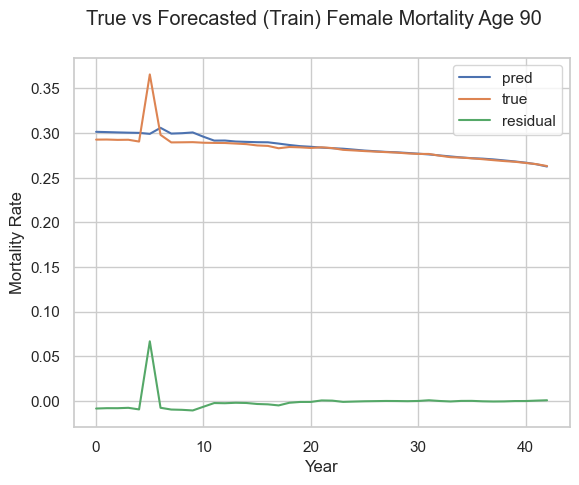

In [70]:
age = 90

plt.plot(female_data_pred[:, age].cpu().numpy(), label="pred")
plt.plot(M_female[10:train_size, age].cpu().numpy(), label="true")
plt.plot((M_female[10:train_size, age] - female_data_pred[:, age]).cpu().numpy(), label="residual")

plt.legend()

plt.suptitle(f"True vs Forecasted (Train) Female Mortality Age {age}")
plt.xlabel("Year")
plt.ylabel("Mortality Rate")
plt.show()

In [71]:
from ta_module.utils import recursive_forecast_with_residual_bootstrap, denormalize

female_simulations_file_path = DOT_ENV.results_dir / "female_mortality_simulations.pt"
if not female_simulations_file_path.exists():
    x, y = test_female_dataset[-1]
    # Dimensi = (10, W)
    x_in = torch.cat([x[1:, :], y])

    # Ubah menjadi dimensi = (1, 10, W)
    x_in = x_in.unsqueeze(0)

    print("=" * 100)
    print(f"Start recursive forecast with residual bootstrap for female mortality:")
    print("=" * 100)
    female_mortality_simulations = recursive_forecast_with_residual_bootstrap(
        model=localglmnet_ensemble,
        x=x_in,
        residuals=female_residuals,
        forecast_horizon=56,
        n_sim=10_000,
    )
    print("=" * 100)
    print(f"Simulation done!")
    print("=" * 100)
    # Denormalize
    print("Start denormalizing...")
    female_mortality_simulations = denormalize(female_mortality_simulations, train_female_mean, train_female_std)
    # Transformasi rentang nilai: R -> (0, 2)
    print("Start inverse link function transformation...")
    female_mortality_simulations = link_fn.inv(female_mortality_simulations)
    print(f"Save simulations to {female_simulations_file_path}")
    torch.save(obj=female_mortality_simulations, f=female_simulations_file_path)
    print("All done!")
else:
    female_mortality_simulations = torch.load(female_simulations_file_path, map_location=DEVICE)

print(female_mortality_simulations[0])
print(female_mortality_simulations.shape)

tensor([[3.7239e-03, 9.3013e-05, 1.2494e-04,  ..., 3.3305e-01, 3.7054e-01,
         4.5442e-01],
        [4.2357e-03, 1.2719e-04, 1.7240e-04,  ..., 3.4132e-01, 3.8230e-01,
         4.6365e-01],
        [4.4678e-03, 1.4677e-04, 2.0188e-04,  ..., 2.5914e-01, 3.0315e-01,
         3.7835e-01],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00]])
torch.Size([10000, 56, 101])


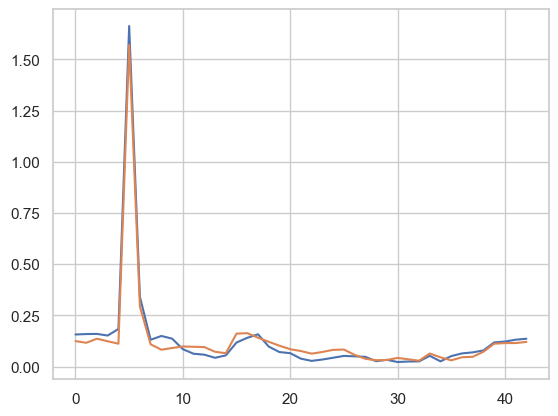

In [72]:
plt.plot(female_residuals.std(dim=2).cpu().numpy())
plt.plot(male_residuals.std(dim=2).cpu().numpy())

plt.show()

# Pembuatan life table

## Stokastik (simulasi peramalan)

### Laki-laki

In [73]:
n_simulations, T, X = male_mortality_simulations.shape

male_1qx = (2.0 * male_mortality_simulations) / (2.0 + male_mortality_simulations)
male_1px = 1.0 - male_1qx

In [74]:
from ta_module.actuarial import compute_ex, compute_kpx_table_from_xstart_dynamic

male_e45 = []
male_kpx_45_100 = []
for i in range(n_simulations):
    kpx_45_100 = compute_kpx_table_from_xstart_dynamic(
        p=male_1px[i],
        x_start=45,
        max_k=56,
        t0=0
    )

    male_kpx_45_100.append(kpx_45_100)
    kp45 = kpx_45_100[0]

    e45 = compute_ex(kp45)
    male_e45.append(e45)

male_e45 = torch.stack(male_e45)
male_kpx_45_100 = torch.stack(male_kpx_45_100)

In [75]:
_, male_e45_sorted_indices = torch.sort(male_e45, descending=False)

male_kpx_45_100_min = male_kpx_45_100[male_e45_sorted_indices[int(0.025 * n_simulations)]]
male_kpx_45_100_med = male_kpx_45_100[male_e45_sorted_indices[int(0.5 * n_simulations)]]
male_kpx_45_100_max = male_kpx_45_100[male_e45_sorted_indices[int(0.975 * n_simulations)]]

male_kqx_45_100_min = 1.0 - male_kpx_45_100_min
male_kqx_45_100_med = 1.0 - male_kpx_45_100_med
male_kqx_45_100_max = 1.0 - male_kpx_45_100_max

### Perempuan

In [76]:
n_simulations, T, X = female_mortality_simulations.shape

female_1qx = (2.0 * female_mortality_simulations) / (2.0 + female_mortality_simulations)
female_1px = 1.0 - female_1qx

In [77]:
from ta_module.actuarial import compute_ex, compute_kpx_table_from_xstart_dynamic

female_e45 = []
female_kpx_45_100 = []
for i in range(n_simulations):
    kpx_45_100 = compute_kpx_table_from_xstart_dynamic(
        p=female_1px[i],
        x_start=45,
        max_k=56,
        t0=0
    )
    female_kpx_45_100.append(kpx_45_100)
    kp45 = kpx_45_100[0]

    e45 = compute_ex(kp45)
    female_e45.append(e45)

female_e45 = torch.stack(female_e45)
female_kpx_45_100 = torch.stack(female_kpx_45_100)

In [78]:
_, female_e45_sorted_indices = torch.sort(female_e45, descending=False)

female_kpx_45_100_min = male_kpx_45_100[female_e45_sorted_indices[int(0.025 * n_simulations)]]
female_kpx_45_100_med = male_kpx_45_100[female_e45_sorted_indices[int(0.5 * n_simulations)]]
female_kpx_45_100_max = male_kpx_45_100[female_e45_sorted_indices[int(0.975 * n_simulations)]]

female_kqx_45_100_min = 1.0 - female_kpx_45_100_min
female_kqx_45_100_med = 1.0 - female_kpx_45_100_med
female_kqx_45_100_max = 1.0 - female_kpx_45_100_max

## Deterministik (TMI IV)

In [79]:
tmi4_df = pd.read_csv("./data/tabel_mortalitas_indonesia_iv.csv", sep=";", decimal=",")
tmi4_df.tail()

,usia,laki-laki,perempuan
96,96,0.25715,0.19155
97,97,0.27419,0.20596
98,98,0.29249,0.22227
99,99,0.31215,0.23736
100,100,0.33331,0.25810


### Laki-laki

In [80]:
male_1qx_tmi4 = torch.from_numpy(tmi4_df.loc[:, "laki-laki"].to_numpy(copy=True, dtype=np.float32).reshape(1, -1)).to(
    DEVICE
)
male_1px_tmi4 = 1.0 - male_1qx_tmi4

In [81]:
male_1px_tmi4

tensor([[0.9948, 0.9995, 0.9996, 0.9997, 0.9997, 0.9997, 0.9998, 0.9998, 0.9998,
         0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9998, 0.9997, 0.9997, 0.9996,
         0.9996, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995, 0.9995,
         0.9994, 0.9994, 0.9993, 0.9992, 0.9992, 0.9991, 0.9991, 0.9990, 0.9989,
         0.9988, 0.9987, 0.9986, 0.9984, 0.9983, 0.9981, 0.9978, 0.9976, 0.9973,
         0.9970, 0.9966, 0.9962, 0.9958, 0.9954, 0.9949, 0.9944, 0.9939, 0.9933,
         0.9927, 0.9921, 0.9915, 0.9910, 0.9906, 0.9903, 0.9900, 0.9898, 0.9895,
         0.9893, 0.9890, 0.9885, 0.9880, 0.9874, 0.9867, 0.9859, 0.9851, 0.9843,
         0.9833, 0.9822, 0.9811, 0.9797, 0.9763, 0.9726, 0.9687, 0.9631, 0.9548,
         0.9447, 0.9327, 0.9177, 0.9052, 0.8953, 0.8847, 0.8730, 0.8605, 0.8473,
         0.8334, 0.8201, 0.8061, 0.7913, 0.7755, 0.7587, 0.7429, 0.7258, 0.7075,
         0.6878, 0.6667]])

In [82]:
from ta_module.actuarial import compute_kpx_table_from_xstart_static

male_kpx_45_100_tmi4 = compute_kpx_table_from_xstart_static(
    p=male_1px_tmi4,
    x_start=45,
    max_k=56,
)

### Perempuan

In [83]:
female_1qx_tmi4 = torch.from_numpy(tmi4_df.loc[:, "perempuan"].to_numpy(copy=True, dtype=np.float32).reshape(1, -1)).to(
    DEVICE
)
female_1px_tmi4 = 1.0 - female_1qx_tmi4

In [84]:
female_kpx_45_100_tmi4 = compute_kpx_table_from_xstart_static(
    p=female_1px_tmi4,
    x_start=45,
    max_k=56,
)

# Perhitungan longevity risk

## Persiapan

In [85]:
populasi_df.head()

,gender,age,value
0,Male,45,2013106
1,Male,46,1965078
2,Male,47,1918556
3,Male,48,1880902
4,Male,49,1836713


In [86]:
populasi_joint_dist_df = (
    populasi_df
    .groupby(['gender', 'age'])["value"]
    .sum()
    .div(populasi_df["value"].sum())
    .rename('prob')
    .reset_index()
)

populasi_joint_dist_df['cdf'] = (
    populasi_joint_dist_df
    .groupby('gender')['prob']
    .cumsum()
)

In [87]:
populasi_joint_dist_df.head()

,gender,age,prob,cdf
0,Female,45,0.036598,0.036598
1,Female,46,0.035845,0.072443
2,Female,47,0.035132,0.107575
3,Female,48,0.034585,0.142160
4,Female,49,0.033901,0.176061


In [88]:
male_age_populasi_prob = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Male"]["prob"]
male_age_populasi_prob = torch.from_numpy(male_age_populasi_prob.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

female_age_populasi_prob = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Female"]["prob"]
female_age_populasi_prob = torch.from_numpy(female_age_populasi_prob.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

In [89]:
male_age_populasi_cdf = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Male"]["cdf"]
male_age_populasi_cdf = torch.from_numpy(male_age_populasi_cdf.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

female_age_populasi_cdf = populasi_joint_dist_df[populasi_joint_dist_df["gender"] == "Female"]["cdf"]
female_age_populasi_cdf = torch.from_numpy(female_age_populasi_cdf.to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

In [90]:
gender_populasi_dist_df = (
    populasi_df.groupby('gender')['value']
    .sum()
    .div(populasi_df['value'].sum())
    .rename('prob')
    .reset_index()
)

gender_populasi_dist_df['cdf'] = gender_populasi_dist_df['prob'].cumsum()

In [91]:
gender_populasi_dist_df

,gender,prob,cdf
0,Female,0.502387,0.502387
1,Male,0.497613,1.000000


In [92]:
male_populasi_prob = torch.tensor(
    gender_populasi_dist_df[gender_populasi_dist_df["gender"] == "Male"]["prob"].iloc[0], device=DEVICE,
    dtype=torch.float32
)

female_populasi_prob = torch.tensor(
    gender_populasi_dist_df[gender_populasi_dist_df["gender"] == "Female"]["prob"].iloc[0], device=DEVICE,
    dtype=torch.float32
)

gender_populasi_cdf = torch.from_numpy(gender_populasi_dist_df["cdf"].to_numpy(copy=True, dtype=np.float32)).to(DEVICE)

In [93]:
age_populasi_given_male_cdf = male_age_populasi_cdf / male_populasi_prob
age_populasi_given_female_cdf = female_age_populasi_cdf / female_populasi_prob

In [94]:
bi_rate_df.head()

,date,bi_rate
0,2024-12-18,0.0600
1,2024-11-20,0.0600
2,2024-10-16,0.0600
3,2024-09-18,0.0600
4,2024-08-21,0.0625


In [95]:
suku_bunga_efektif_tahunan = torch.tensor(bi_rate_df["bi_rate"].mean(), device=DEVICE, dtype=torch.float32)
suku_bunga_efektif_tahunan

tensor(0.0474)

In [96]:
suku_bunga_nominal_bulanan = 12.0 * ((1.0 + suku_bunga_efektif_tahunan).pow(1.0 / 12.0) - 1.0)
suku_bunga_nominal_bulanan

tensor(0.0464)

In [97]:
from torch.distributions import LogNormal

premi_lognormal_rv = LogNormal(loc=5.926, scale=0.605)

In [98]:
start_age = 45
end_age = 60
m = 12

from ta_module.actuarial import compute_m_annuity_epv, compute_m_annuity_var, compute_m_annuity_epv2
from torch import Tensor


def wrapper_compute_m_annuity_epv(
    kpx: Tensor,
    gender_age_prob: Tensor
) -> Tensor:
    return compute_m_annuity_epv(
        start_age=start_age,
        end_age=end_age,
        m=m,
        i=suku_bunga_efektif_tahunan,
        kpx=kpx,
        gender_age_prob=gender_age_prob,
    )


def wrapper_compute_m_annuity_var(
    kpx: Tensor,
    gender_age_prob: Tensor
) -> Tensor:
    return compute_m_annuity_var(
        start_age=start_age,
        end_age=end_age,
        m=m,
        i=suku_bunga_efektif_tahunan,
        kpx=kpx,
        gender_age_prob=gender_age_prob,
    )


def wrapper_compute_m_annuity_epv2(
    kpx: Tensor,
    gender_age_prob: Tensor
) -> Tensor:
    return compute_m_annuity_epv2(
        start_age=start_age,
        end_age=end_age,
        m=m,
        i=suku_bunga_efektif_tahunan,
        kpx=kpx,
        gender_age_prob=gender_age_prob,
    )

In [99]:
N = [1, 10, 100, 1_000, 10_000, 100_000, 1_000_000, 10_000_000, 100_000_000, 1_000_000_000]

## Kerangka deterministik

### EPV

In [100]:
male_tmi4_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_tmi4,
    gender_age_prob=male_age_populasi_prob
)

male_tmi4_epv

tensor(90.9883)

In [101]:
female_tmi4_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_tmi4,
    gender_age_prob=female_age_populasi_prob
)

female_tmi4_epv

tensor(95.1843)

In [102]:
tmi4_epv = male_tmi4_epv + female_tmi4_epv
tmi4_epv

tensor(186.1726)

In [103]:
expected_benefit_tmi4 = (premi_lognormal_rv.mean + 50) / tmi4_epv
print(f"Ekspektasi manfaat per bulan anuitas jiwa deterministik (dalam juta rupiah) = {expected_benefit_tmi4:.6f}")

Ekspektasi manfaat per bulan anuitas jiwa deterministik (dalam juta rupiah) = 2.685112


In [104]:
portfolio_tmi4_epv = {}
for n in N:
    portfolio_tmi4_epv[n] = n * expected_benefit_tmi4 * tmi4_epv
    print(f"N = {n}\nEPV portfolio deterministik = {portfolio_tmi4_epv[n]:.6f}\n")

N = 1
EPV portfolio deterministik = 499.894287

N = 10
EPV portfolio deterministik = 4998.943359

N = 100
EPV portfolio deterministik = 49989.425781

N = 1000
EPV portfolio deterministik = 499894.312500

N = 10000
EPV portfolio deterministik = 4998943.000000

N = 100000
EPV portfolio deterministik = 49989432.000000

N = 1000000
EPV portfolio deterministik = 499894304.000000

N = 10000000
EPV portfolio deterministik = 4998943232.000000

N = 100000000
EPV portfolio deterministik = 49989431296.000000

N = 1000000000
EPV portfolio deterministik = 499894288384.000000



### Varians

In [105]:
male_tmi4_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_tmi4,
    gender_age_prob=male_age_populasi_prob
)

male_tmi4_var

tensor(2484.6086)

In [106]:
male_tmi4_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_tmi4,
    gender_age_prob=male_age_populasi_prob
)

male_tmi4_epv2

tensor(16659.9922)

In [107]:
female_tmi4_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_tmi4,
    gender_age_prob=female_age_populasi_prob
)

female_tmi4_var

tensor(2220.6824)

In [108]:

female_tmi4_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=female_kpx_45_100_tmi4,
    gender_age_prob=female_age_populasi_prob
)

female_tmi4_epv2

tensor(18058.8633)

In [109]:
tmi4_epv2 = male_tmi4_epv2 + female_tmi4_epv2
tmi4_var = male_tmi4_var + female_tmi4_var
tmi4_total_var = tmi4_var + tmi4_epv2 - tmi4_epv.pow(2)

In [110]:
portfolio_tmi4_var = {}

E_B = expected_benefit_tmi4
# VAR(B) = VAR(P / E(Y)) = VAR([P* + 50] / E(Y)) = 1 / E(Y)^2 * VAR(P*)
VAR_B = 1 / tmi4_epv.pow(2) * premi_lognormal_rv.variance
# VAR(B) = E(B^2) - E(B)^2 => E(B^2) = E(B)^2 + VAR(B)
E_B2 = E_B.pow(2) + VAR_B

E_Y = tmi4_epv
VAR_Y = tmi4_total_var
E_Y2 = E_Y.pow(2) + VAR_Y

for n in N:
    portfolio_tmi4_var[n] = n * (E_B2 * E_Y2 - (E_B * E_Y).pow(2))
    print(f"N = {n}\nVAR portfolio deterministik = {portfolio_tmi4_var[n]:.6f}\n")

N = 1
VAR portfolio deterministik = 136104.140625

N = 10
VAR portfolio deterministik = 1361041.375000

N = 100
VAR portfolio deterministik = 13610414.000000

N = 1000
VAR portfolio deterministik = 136104144.000000

N = 10000
VAR portfolio deterministik = 1361041408.000000

N = 100000
VAR portfolio deterministik = 13610414080.000000

N = 1000000
VAR portfolio deterministik = 136104140800.000000

N = 10000000
VAR portfolio deterministik = 1361041424384.000000

N = 100000000
VAR portfolio deterministik = 13610413719552.000000

N = 1000000000
VAR portfolio deterministik = 136104141389824.000000



### Koefisien variasi

In [111]:
portfolio_tmi4_koefisien_variasi = {}
for n in N:
    portfolio_tmi4_koefisien_variasi[n] = portfolio_tmi4_var[n].sqrt() / portfolio_tmi4_epv[n]
    print(f"N = {n}\nKoefisien variasi portfolio deterministik = {portfolio_tmi4_koefisien_variasi[n]:.6f}\n")

N = 1
Koefisien variasi portfolio deterministik = 0.738002

N = 10
Koefisien variasi portfolio deterministik = 0.233377

N = 100
Koefisien variasi portfolio deterministik = 0.073800

N = 1000
Koefisien variasi portfolio deterministik = 0.023338

N = 10000
Koefisien variasi portfolio deterministik = 0.007380

N = 100000
Koefisien variasi portfolio deterministik = 0.002334

N = 1000000
Koefisien variasi portfolio deterministik = 0.000738

N = 10000000
Koefisien variasi portfolio deterministik = 0.000233

N = 100000000
Koefisien variasi portfolio deterministik = 0.000074

N = 1000000000
Koefisien variasi portfolio deterministik = 0.000023



In [112]:
portfolio_tmi4_epv.values()

dict_values([tensor(499.8943), tensor(4998.9434), tensor(49989.4258), tensor(499894.3125), tensor(4998943.), tensor(49989432.), tensor(4.9989e+08), tensor(4.9989e+09), tensor(4.9989e+10), tensor(4.9989e+11)])

In [113]:
tmi4_longevity_risk = {
    "epv"              : [v.item() for v in portfolio_tmi4_epv.values()],
    "var"              : [v.item() for v in portfolio_tmi4_var.values()],
    "koefisien_variasi": [v.item() for v in portfolio_tmi4_koefisien_variasi.values()]
}

pd.DataFrame(tmi4_longevity_risk, index=N).to_csv(DOT_ENV.results_dir / "tmi4_longevity_risk.csv", sep=";", decimal=",")

## Kerangka stokastik

### EPV

In [114]:
male_min_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_min,
    gender_age_prob=male_age_populasi_prob
)

male_min_epv

tensor(93.3238)

In [115]:
male_med_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_med,
    gender_age_prob=male_age_populasi_prob
)

male_med_epv

tensor(94.3227)

In [116]:
male_max_epv = wrapper_compute_m_annuity_epv(
    kpx=male_kpx_45_100_max,
    gender_age_prob=male_age_populasi_prob
)

male_max_epv

tensor(97.5860)

In [117]:
female_min_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_min,
    gender_age_prob=female_age_populasi_prob
)

female_min_epv

tensor(93.0879)

In [118]:
female_med_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_med,
    gender_age_prob=female_age_populasi_prob
)

female_med_epv

tensor(92.6758)

In [119]:
female_max_epv = wrapper_compute_m_annuity_epv(
    kpx=female_kpx_45_100_max,
    gender_age_prob=female_age_populasi_prob
)

female_max_epv

tensor(93.5163)

In [120]:
min_epv = male_min_epv + female_min_epv
med_epv = male_med_epv + female_med_epv
max_epv = male_max_epv + female_max_epv

In [121]:
r_min = 0.15
r_med = 0.70
r_max = 0.15

stokastik_epv = r_min * min_epv + r_med * med_epv + r_max * max_epv
print(f"EPV anuitas jiwa stokastik = {stokastik_epv:.6f}")

EPV anuitas jiwa stokastik = 187.525986


In [122]:
expected_benefit_min = (premi_lognormal_rv.mean + 50) / min_epv
expected_beneit_med = (premi_lognormal_rv.mean + 50) / med_epv
expected_beneit_max = (premi_lognormal_rv.mean + 50) / max_epv

expected_benefit_stokastik = (
        r_min * expected_benefit_min +
        r_med * expected_beneit_med +
        r_max * expected_beneit_max
)
print(f"Ekspektasi manfaat bulanan anuitas jiwa stokastik (dalam juta rupiah) = {expected_benefit_stokastik:.6f}")

Ekspektasi manfaat bulanan anuitas jiwa stokastik (dalam juta rupiah) = 2.665905


In [123]:
portfolio_stokastik_epv = {}
for n in N:
    portfolio_stokastik_epv[n] = n * expected_benefit_stokastik * stokastik_epv
    print(f"\nN = {n}\nEPV portfolio stokastik = {portfolio_stokastik_epv[n]:.6f}")


N = 1
EPV portfolio stokastik = 499.926453

N = 10
EPV portfolio stokastik = 4999.264648

N = 100
EPV portfolio stokastik = 49992.648438

N = 1000
EPV portfolio stokastik = 499926.468750

N = 10000
EPV portfolio stokastik = 4999265.000000

N = 100000
EPV portfolio stokastik = 49992648.000000

N = 1000000
EPV portfolio stokastik = 499926464.000000

N = 10000000
EPV portfolio stokastik = 4999264768.000000

N = 100000000
EPV portfolio stokastik = 49992646656.000000

N = 1000000000
EPV portfolio stokastik = 499926433792.000000


### Varians

In [124]:
male_min_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_min,
    gender_age_prob=male_age_populasi_prob
)

male_med_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_med,
    gender_age_prob=male_age_populasi_prob
)

male_max_var = wrapper_compute_m_annuity_var(
    kpx=male_kpx_45_100_max,
    gender_age_prob=male_age_populasi_prob
)

In [125]:
female_min_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_min,
    gender_age_prob=female_age_populasi_prob
)

female_med_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_med,
    gender_age_prob=female_age_populasi_prob
)

female_max_var = wrapper_compute_m_annuity_var(
    kpx=female_kpx_45_100_max,
    gender_age_prob=female_age_populasi_prob
)

In [126]:
min_var = male_min_var + female_min_var
med_var = male_med_var + female_med_var
max_var = male_max_var + female_max_var

In [127]:
male_min_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_min,
    gender_age_prob=male_age_populasi_prob
)

male_med_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_med,
    gender_age_prob=male_age_populasi_prob
)

male_max_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_max,
    gender_age_prob=male_age_populasi_prob
)

In [128]:
female_min_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=male_kpx_45_100_min,
    gender_age_prob=female_age_populasi_prob
)

female_med_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=female_kpx_45_100_med,
    gender_age_prob=female_age_populasi_prob
)

female_max_epv2 = wrapper_compute_m_annuity_epv2(
    kpx=female_kpx_45_100_max,
    gender_age_prob=female_age_populasi_prob
)

In [129]:
min_epv2 = male_min_epv2 + female_min_epv2
med_epv2 = male_med_epv2 + female_med_epv2
max_epv2 = male_max_epv2 + female_max_epv2

In [130]:
min_total_var = min_var + min_epv2 - min_epv.pow(2)
med_total_var = med_var + med_epv2 - med_epv.pow(2)
max_total_var = max_var + max_epv2 - max_epv.pow(2)

In [131]:
portfolio_stokastik_var = {}
portfolio_stokastik_E_VAR = {}
portfolio_stokastik_VAR_E = {}

N_bar = 0

E_B = expected_benefit_stokastik
VAR_B = 1 / stokastik_epv.pow(2) * premi_lognormal_rv.variance
E_B2 = VAR_B + E_B.pow(2)

E_Y_min = min_epv
E_Y_med = med_epv
E_Y_max = max_epv

E_Y2_min = min_total_var + min_epv.pow(2)
E_Y2_med = med_total_var + med_epv.pow(2)
E_Y2_max = max_total_var + max_epv.pow(2)

E_EB_EY_2 = (
        r_min * (E_B * E_Y_min).pow(2) +
        r_med * (E_B * E_Y_med).pow(2) +
        r_max * (E_B * E_Y_max).pow(2)
)

E_EB_EY = (
        r_min * (E_B * E_Y_min) +
        r_med * (E_B * E_Y_med) +
        r_max * (E_B * E_Y_max)
)

for n in N:
    E_VAR = (
            r_min * (E_B2 * E_Y2_min - (E_B * E_Y_min).pow(2)) +
            r_med * (E_B2 * E_Y2_med - (E_B * E_Y_med).pow(2)) +
            r_max * (E_B2 * E_Y2_max - (E_B * E_Y_max).pow(2))
    )
    VAR_E = (E_EB_EY_2 - E_EB_EY.pow(2))
    portfolio_stokastik_var[n] = n * E_VAR + (n ** 2) * VAR_E
    portfolio_stokastik_E_VAR[n] = n * E_VAR
    portfolio_stokastik_VAR_E[n] = (n ** 2) * VAR_E

    N_bar = E_VAR / VAR_E

    print(f"N = {n}")
    print(f"N_bar = {N_bar:.4f}")
    print(f"VAR portfolio stokastik = {portfolio_stokastik_var[n]:.6f}\n")

N = 1
N_bar = 8916.6494
VAR portfolio stokastik = 145608.500000

N = 10
N_bar = 8916.6494
VAR portfolio stokastik = 1457554.500000

N = 100
N_bar = 8916.6494
VAR portfolio stokastik = 14722498.000000

N = 1000
N_bar = 8916.6494
VAR portfolio stokastik = 161920304.000000

N = 10000
N_bar = 8916.6494
VAR portfolio stokastik = 3088734208.000000

N = 100000
N_bar = 8916.6494
VAR portfolio stokastik = 177840472064.000000

N = 1000000
N_bar = 8916.6494
VAR portfolio stokastik = 16473717211136.000000

N = 10000000
N_bar = 8916.6494
VAR portfolio stokastik = 1634268342124544.000000

N = 100000000
N_bar = 8916.6494
VAR portfolio stokastik = 163295807645155328.000000

N = 1000000000
N_bar = 8916.6494
VAR portfolio stokastik = 16328269940496793600.000000



### Koefisien variasi

In [132]:
portfolio_stokastik_koefisien_variasi = {}
for n in N:
    portfolio_stokastik_koefisien_variasi[n] = portfolio_stokastik_var[n].sqrt() / portfolio_stokastik_epv[n]
    print(f"N = {n}")
    print(f"N_bar = {N_bar:.4f}")
    print(f"Koefisien variasi portfolio stokastik = {portfolio_stokastik_koefisien_variasi[n]:.6f}\n")

N = 1
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.763286

N = 10
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.241494

N = 100
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.076751

N = 1000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.025453

N = 10000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.011117

N = 100000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.008435

N = 1000000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.008119

N = 10000000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.008086

N = 100000000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.008083

N = 1000000000
N_bar = 8916.6494
Koefisien variasi portfolio stokastik = 0.008083



In [133]:
stokastik_longevity_risk = {
    "epv"              : [v.item() for v in portfolio_stokastik_epv.values()],
    "E_VAR"            : [v.item() for v in portfolio_stokastik_E_VAR.values()],
    "VAR_E"            : [v.item() for v in portfolio_stokastik_VAR_E.values()],
    "var"              : [v.item() for v in portfolio_stokastik_var.values()],
    "koefisien_variasi": [v.item() for v in portfolio_stokastik_koefisien_variasi.values()],
    "N_bar"            : N_bar.item()
}

pd.DataFrame(stokastik_longevity_risk, index=N).to_csv(
    DOT_ENV.results_dir / "stokastik_longevity_risk.csv", sep=";", decimal=","
    )

# Perhitungan value at risk

## Kerangka deterministik

In [150]:
from torch import Tensor

from ta_module.actuarial import create_fractional_m_cdf
from ta_module.utils import inverse_transform_sampling

def sampling_gender(
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(0, 2).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = gender_populasi_cdf.expand(n_sims, n_samples, -1).contiguous()
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf,
    )

    return samples


def sampling_age(
    start_age: int,
    end_age: int,
    gender: Tensor,
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(start_age, end_age + 1).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = torch.where(gender == 0, age_populasi_given_male_cdf, age_populasi_given_female_cdf).to(device)
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf,
    )

    return samples

def sampling_curtate_m_future_lifetime(
    fractional_m_cdf: Tensor,
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    x = torch.arange(0, fractional_m_cdf.shape[-1]).expand(n_sims, n_samples, -1).contiguous().to(device)
    cdf = fractional_m_cdf
    samples = inverse_transform_sampling(
        x=x,
        cdf=cdf,
    )

    return samples

In [151]:
def sampling_portfolio_value(
    male_kpx: Tensor,
    female_kpx: Tensor,
    n_sims: int = 10_000,
    n_samples: int = 1,
    device: str = "cpu"
) -> Tensor:
    gender_samples = sampling_gender(
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    age_samples = sampling_age(
        start_age=45,
        end_age=60,
        gender=gender_samples,
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    kpx = torch.stack([male_kpx, female_kpx], dim=0)
    gender_idx = gender_samples.squeeze().long()
    age_idx = (age_samples - start_age).squeeze().long()
    fractional_m_cdf = create_fractional_m_cdf(kpx=kpx[gender_idx, age_idx], m=m).view(n_sims, n_samples, -1)

    premi_samples = 50 + premi_lognormal_rv.sample(sample_shape=(n_sims, n_samples, 1)).to(DEVICE)
    benefit_samples = premi_samples / tmi4_epv

    curtate_m_future_lifetime_samples = sampling_curtate_m_future_lifetime(
        fractional_m_cdf=fractional_m_cdf,
        n_sims=n_sims,
        n_samples=n_samples,
        device=device
    )

    i_m = suku_bunga_nominal_bulanan
    v_m = 1 / (1 + i_m / m)
    d_m = (i_m / m) * v_m

    annuity_value = (1 - v_m.pow(curtate_m_future_lifetime_samples + 1)) / d_m - 1
    portfolio_value = (benefit_samples * annuity_value).sum(dim=1)

    return portfolio_value

In [154]:
n_simulations = 10_000
chunk_threshold = 100

portfolio_simulations_tmi4 = {}
for n in N:
    print(f"Mulai simulasi portfolio N = {n}")
    chunk_size = n
    if n > chunk_threshold:
        chunk_size = chunk_threshold

    quotient, remainder = divmod(n, chunk_size)
    portfolio_simulation_value = torch.zeros(size=(n_simulations, 1), device=DEVICE)
    for _ in range(quotient):
        portfolio_simulation_value += sampling_portfolio_value(
            male_kpx=male_kpx_45_100_tmi4,
            female_kpx=female_kpx_45_100_tmi4,
            n_sims=n_simulations,
            n_samples=chunk_size,
            device=DEVICE
        )

    if remainder > 0:
        portfolio_simulation_value += sampling_portfolio_value(
            male_kpx=male_kpx_45_100_tmi4,
            female_kpx=female_kpx_45_100_tmi4,
            n_sims=n_simulations,
            n_samples=remainder,
            device=DEVICE
        )

    portfolio_simulations_tmi4[n] = portfolio_simulation_value
    print(f"Simulasi portfolio N = {n} selesai")
    print(f"Hasil: {portfolio_simulations_tmi4[n][:5]}")

Mulai simulasi portfolio N = 1
Simulasi portfolio N = 1 selesai
Hasil: tensor([[-0.3899],
        [-1.4202],
        [-0.3158],
        [-0.1647],
        [-2.4180]])
Mulai simulasi portfolio N = 10
Simulasi portfolio N = 10 selesai
Hasil: tensor([[ -5.0960],
        [ -4.5613],
        [ -4.7058],
        [-10.2580],
        [ -7.9550]])
Mulai simulasi portfolio N = 100


KeyboardInterrupt: 